<a href="https://colab.research.google.com/github/Miguithub/Wavelets/blob/vpn_btc/Wavelets_VNP_BTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# LIBRERIAS 1

In [1]:
!pip install statsmodels

In [2]:
import requests
import pandas as pd
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


---

# DE

In [4]:
btc = pd.read_parquet('/content/drive/MyDrive/mf12024.parquet')

In [ ]:
# eth = pd.read_parquet('/content/drive/MyDrive/1meth.parquet')

In [ ]:
# sol = pd.read_parquet('/content/drive/MyDrive/1msol.parquet')

Check

In [5]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   open_time               int64  
 1   open                    float64
 2   high                    float64
 3   low                     float64
 4   close                   float64
 5   volume                  float64
 6   close_time              int64  
 7   quote_volume            float64
 8   trade_count             int64  
 9   taker_buy_base_volume   float64
 10  taker_buy_quote_volume  float64
 11  ignore                  int64  
dtypes: float64(8), int64(4)
memory usage: 2.8 GB


In [ ]:
btc.tail()

,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore
31622395,1735689595000,93576.00,93576.01,93576.00,93576.01,0.00083,1735689595999,77.668087,2,0.00067,62.695927,0
31622396,1735689596000,93576.01,93576.01,93576.01,93576.01,0.00000,1735689596999,0.000000,0,0.00000,0.000000,0
31622397,1735689597000,93576.01,93576.01,93576.01,93576.01,0.00000,1735689597999,0.000000,0,0.00000,0.000000,0
31622398,1735689598000,93576.01,93576.01,93576.01,93576.01,0.00094,1735689598999,87.961449,3,0.00094,87.961449,0
31622399,1735689599000,93576.00,93576.00,93576.00,93576.00,0.00217,1735689599999,203.059920,3,0.00000,0.000000,0


In [ ]:
btc.head()

,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,1704067200000,42283.58,42283.59,42283.58,42283.58,0.07625,1704067200999,3224.123141,21,0.01658,701.061922,0
1,1704067201000,42283.59,42283.59,42283.58,42283.58,1.37528,1704067201999,58151.769471,51,0.75683,32001.489420,0
2,1704067202000,42283.58,42283.59,42283.58,42283.58,0.18867,1704067202999,7977.643051,9,0.00124,52.431652,0
3,1704067203000,42283.58,42283.59,42283.58,42283.59,0.83488,1704067203999,35301.720464,39,0.51935,21959.982467,0
4,1704067204000,42283.58,42283.59,42283.58,42283.59,0.23809,1704067204999,10067.297927,17,0.03653,1544.619543,0


Cleaness

In [6]:
import pandas as pd

# Usá el nombre real de tu columna temporal
t = pd.to_datetime(btc["close_time"])

# diferencias entre timestamps en segundos
d = t.diff().dt.total_seconds()

# chequeo de equidistancia
es_equidistante = d.iloc[1:].nunique() == 1

print("Equidistante:", es_equidistante)
print("Intervalo único (segundos):", d.iloc[1] if es_equidistante else "No uniforme")

Equidistante: True
Intervalo único (segundos): 1e-06


In [7]:
del t, d
import gc
gc.collect()

17

In [8]:
btc.drop(columns=btc.columns[0], inplace=True)
btc["time"] = pd.to_datetime(btc["close_time"] // 1000, unit="s")
cols = ["time"] + [c for c in btc.columns if c not in ["time", "close_time"]]
btc = btc[cols]

In [9]:
btc["day"] = btc["time"].dt.weekday + 1
btc.loc[btc["day"] == 7, "day"] = 0

In [ ]:
btc.tail()

,time,open,high,low,close,volume,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore,day
31622395,2024-12-31 23:59:55,93576.00,93576.01,93576.00,93576.01,0.00083,77.668087,2,0.00067,62.695927,0,2
31622396,2024-12-31 23:59:56,93576.01,93576.01,93576.01,93576.01,0.00000,0.000000,0,0.00000,0.000000,0,2
31622397,2024-12-31 23:59:57,93576.01,93576.01,93576.01,93576.01,0.00000,0.000000,0,0.00000,0.000000,0,2
31622398,2024-12-31 23:59:58,93576.01,93576.01,93576.01,93576.01,0.00094,87.961449,3,0.00094,87.961449,0,2
31622399,2024-12-31 23:59:59,93576.00,93576.00,93576.00,93576.00,0.00217,203.059920,3,0.00000,0.000000,0,2


In [10]:
cols = ["time", "day"] + [c for c in btc.columns if c not in ["time", "day"]]
btc = btc[cols]

In [11]:
btc["close_ln"] = np.log(btc["close"])

In [12]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 13 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   time                    datetime64[ns]
 1   day                     int64         
 2   open                    float64       
 3   high                    float64       
 4   low                     float64       
 5   close                   float64       
 6   volume                  float64       
 7   quote_volume            float64       
 8   trade_count             int64         
 9   taker_buy_base_volume   float64       
 10  taker_buy_quote_volume  float64       
 11  ignore                  int64         
 12  close_ln                float64       
dtypes: datetime64[ns](1), float64(9), int64(3)
memory usage: 3.1 GB


#Wlts VB non parametric

## r_10 *


In [ ]:
df10 = btc.iloc[:, [0, 1, 5, 12]]
df10 = df10.iloc[::10].copy()
df10["r"] = df10["close_ln"].diff()
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 120.6 MB


Media: 2.5120653730677365e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.000290376799758221
Skew: -0.6644163965928828
Deciles:
d1 : -0.00026676758983050773
d2 : -0.00012998375213797424
d3 : -4.888213497800108e-05
d4 : -1.5214678050767816e-07
d5 : 0.0
d6 : 1.5112582580911745e-07
d7 : 4.940751749771264e-05
d8 : 0.00013040859643567173
d9 : 0.00026780246966211566
Percentiles mas altos:
d95 : 0.00041478295868806436
d96 : 0.0004653834598781969
d97 : 0.0005335308049401632
d98 : 0.0006348627043620058
d99 : 0.00082801840637032
d100 : 0.01430715525476245
Permiles
p970 : 0.0005335308049401632
p971 : 0.000541870576748817
p972 : 0.0005504572842127686
p973 : 0.0005592279938695307
p974 : 0.0005682853087387143
p975 : 0.0005778918045185033
p976 : 0.0005881440891452153
p977 : 0.0005988980718875149
p978 : 0.0006100198064358578
p979 : 0.0006219765619111564
p980 : 0.0006348627043620058
p981 : 0.0006483678177292883
p982 : 0.0006626566118075346
p983 : 0.0006780131169875573
p984 : 0.000694884315670125
p985 : 0

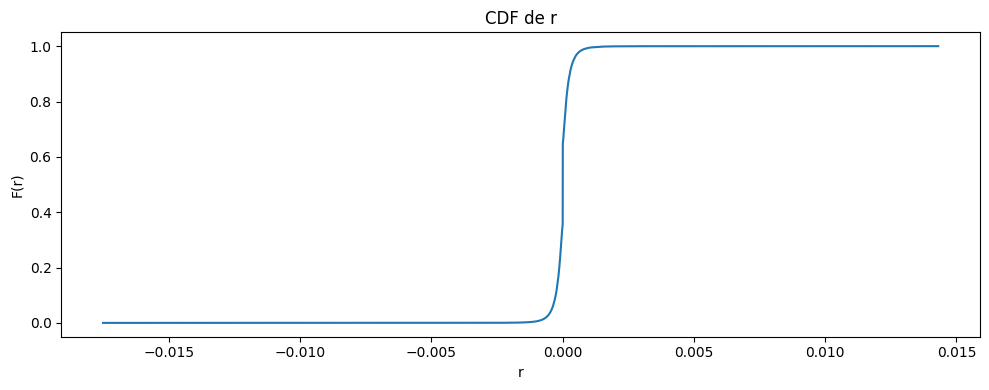

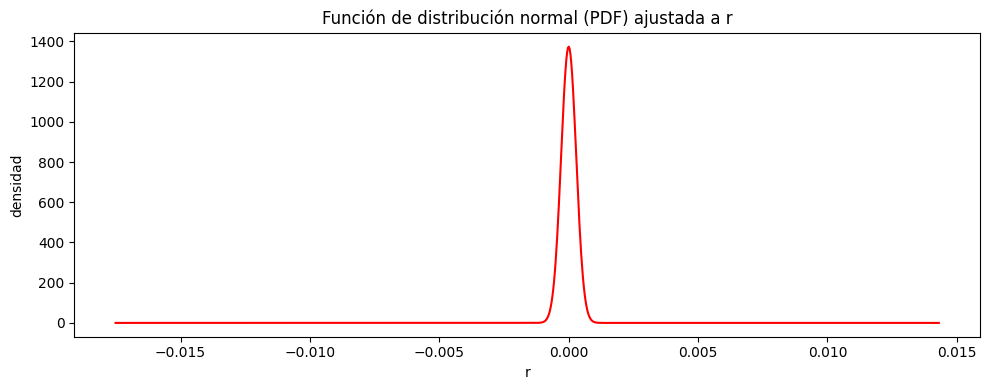

In [ ]:
import numpy as np
from scipy.stats import skew, norm

s = df10["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df10["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.1040912948216904
P0 (eps): 0.1040912948216904
d0 : -0.02270720738637877
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
Percentiles mas bajos:
d0 : -0.0010524389561297482
d1 : -0.000798699366188714
d2 : -0.000668114432760035
d3 : -0.000582131826901005
d4 : -0.0005192846253105614
d5 : -0.00047030662868812807
d6 : -0.0004299274431113105
d7 : -0.00039582443766040143
d8 : -0.0003657379544529
d9 : -0.0003397565633194226
d10 : -0.0003161667496839229
d11 : -0.0002952106950851245
d12 : -0.00027621478841250634
d13 : -0.0002581737193119658
d14 : -0.00024143300978510143
d15 : -0.00022618347367818356
d16 : -0.0002116719089413621
d17 : -0.00019894742109004683
d18 : -0.00018618756073452404
d19 : -0.00017440182492616427


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.863120          0.136880        0.018851   
1    sym6  3      0.862229          0.137771        0.028615   
2     db6  3      0.862821          0.137179        0.029370   
3    sym4  3      0.862455          0.137545        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        0.980421   788.172962  
1             0.003599        0.976053  1527.291776  
2             0.003750        0.976940  1623.675248  
3             0.003572        0.974309  1625.363930  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.15530536 0.29846131 0.54623333]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.983487          0.016513        0.018851   
1    sym6  6      0.983535          0.016465        0.028615   
2     db6  6      0.983684          0.016316        0.029370   
3    sym4  6      0.983506          0.016494        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        1.349098   788.172962  
1             0.003599        1.346415  1527.291776  
2             0.003750        1.346673  1623.675248  
3             0.003572        1.344478  1625.363930  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.00458471 0.00918803 0.01832132 0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.01748336 0.03503767 0.06986659 0.13629791 0.26193334 0.47938114]


###vnp teorica

In [ ]:
df10["RV_r"] = df10["r"]**2

Energia local suavizada

In [ ]:
import numpy as np, pywt

x = df10["r"].to_numpy(dtype=float)
x = np.nan_to_num(x, nan=0.0)  # si tenés NaN, swt revienta; mejor imputación simple

J = 6
w = "db4"
n = x.size
m = 1 << J
pad = (-n) % m
xp = np.pad(x, (0, pad), mode="edge") if pad else x

coeffs = pywt.swt(xp, w, level=J, trim_approx=False)

# Detalles por nivel
for j in range(1, J + 1):
    df10[f"j{j}"] = coeffs[J - j][1][:n]   # cDj
df10[f"a{J}"] = coeffs[-1][0][:n]          # cAJ

In [ ]:
df10.info()

Bloque elegido:
Inicio: 2024-06-14 06:44:13
Fin   : 2024-06-14 06:49:13


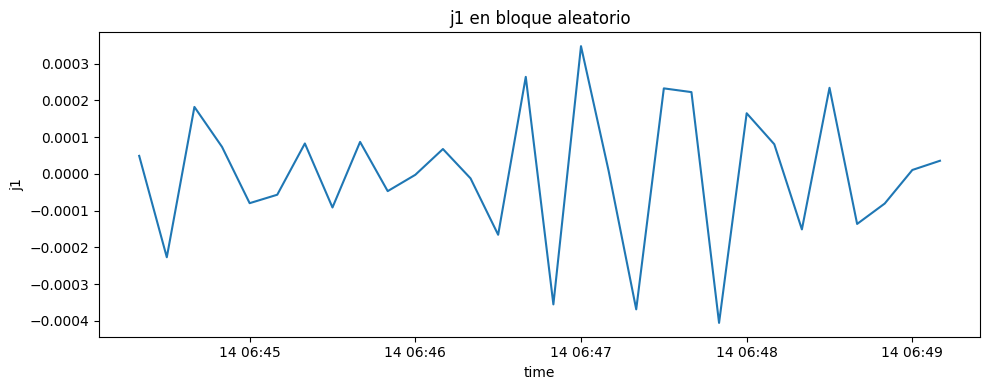

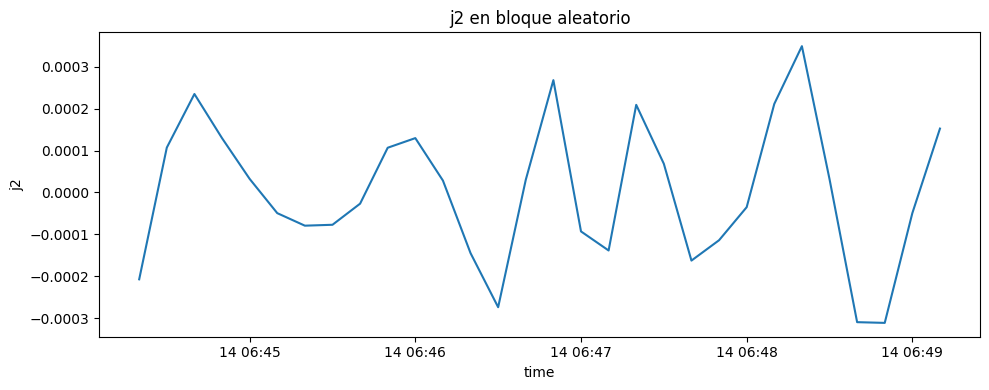

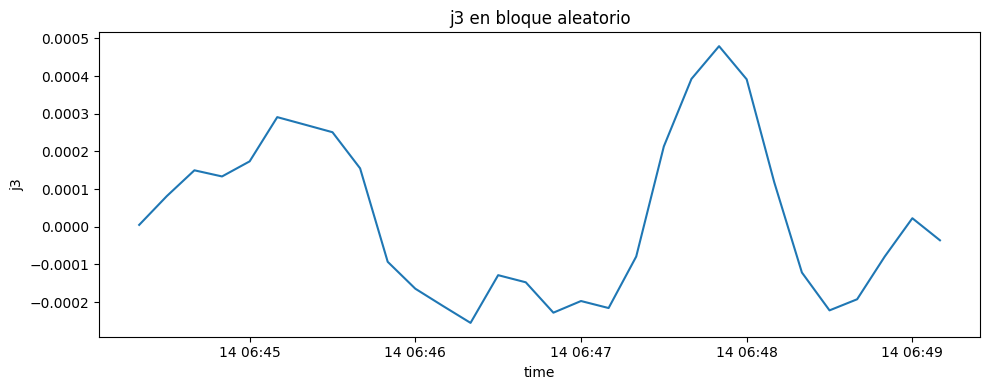

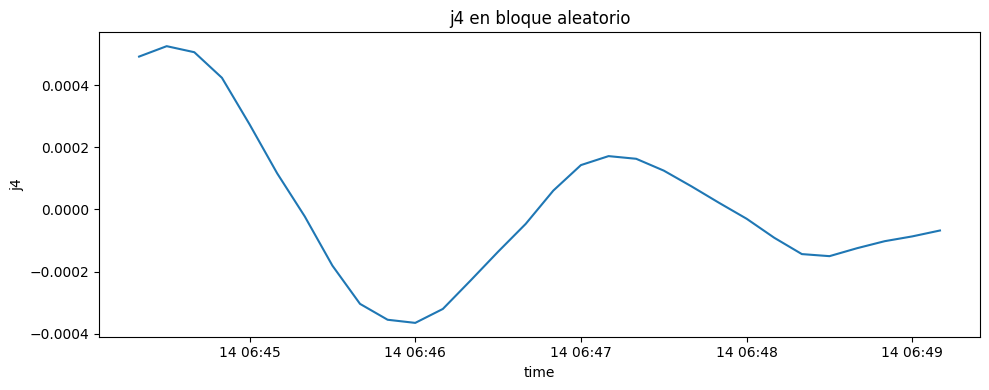

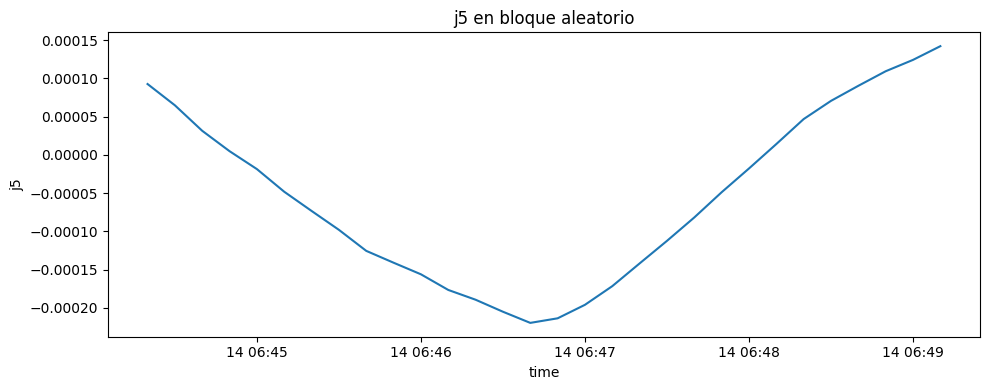

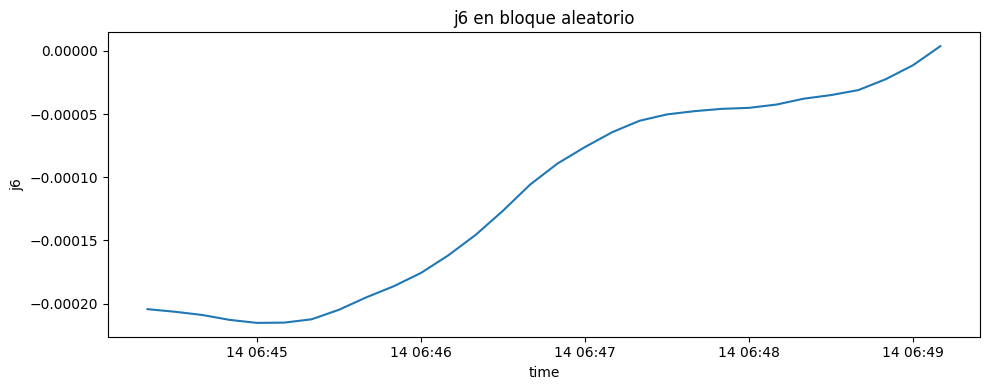

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 7)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

In [ ]:
for j in range(1, 7):
    c = df10[f"j{j}"]
    df10[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

Bloque elegido:
Inicio: 2024-06-14 08:06:46
Fin   : 2024-06-14 08:11:46


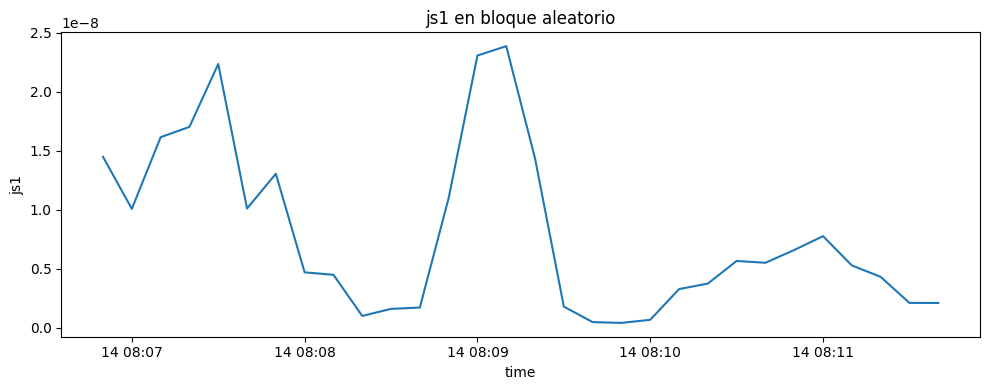

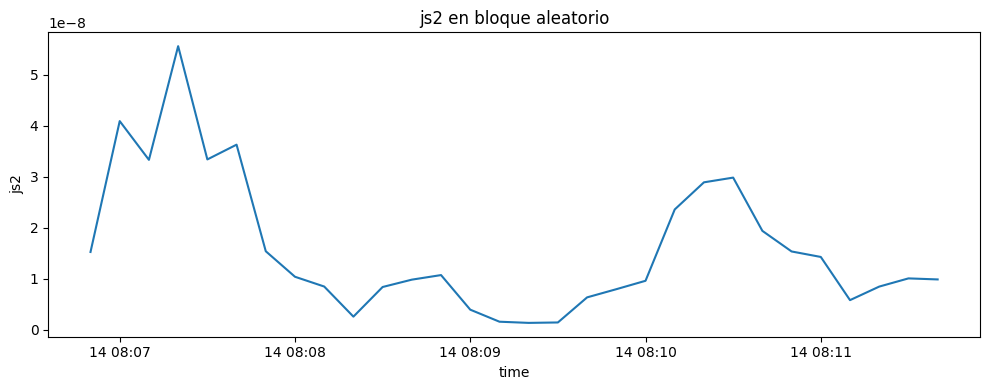

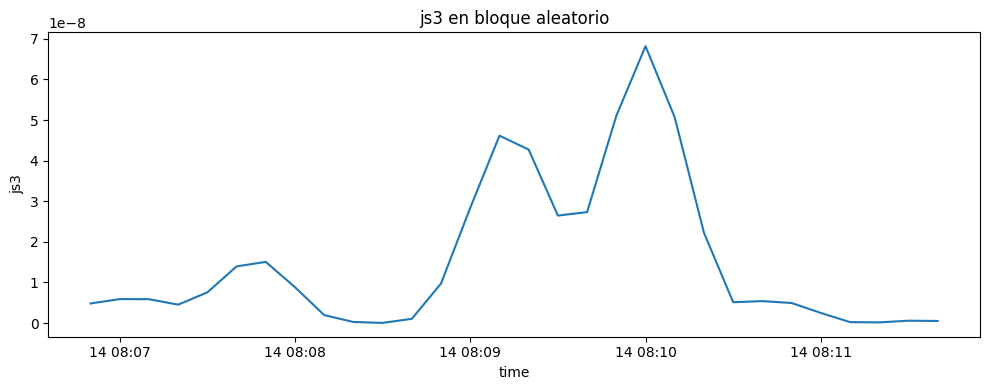

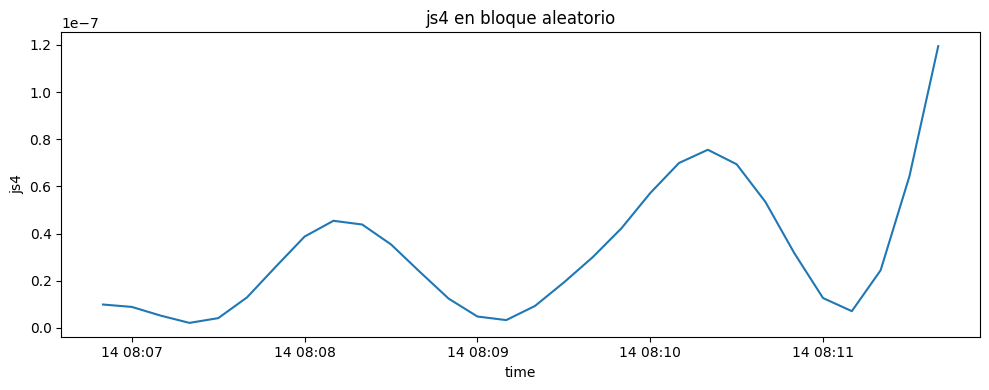

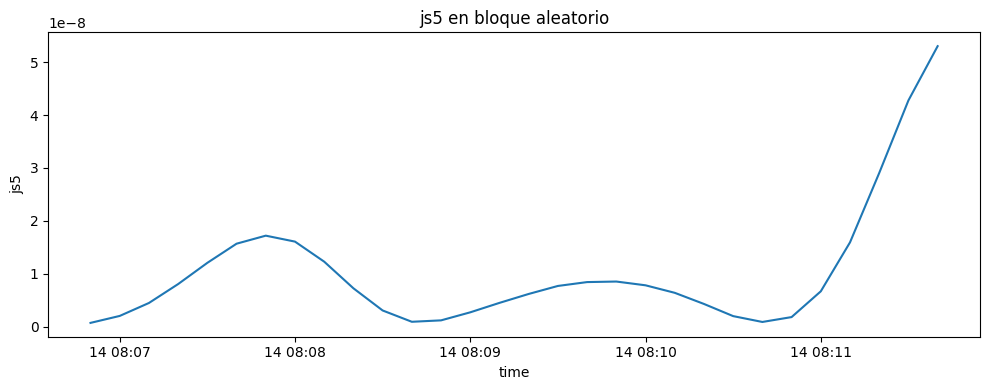

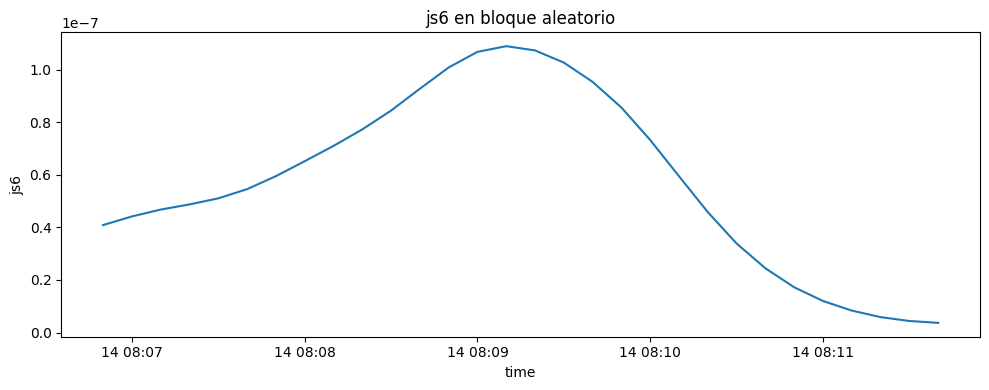

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 7)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()


*Eshort, Emedium and ELong all RAW*

In [ ]:
df10["des"] = df10["j1"] + df10["j2"]
df10["dem"] = df10["j3"] + df10["j4"]
df10["del"] = df10["j5"] + df10["j6"]

In [ ]:
s = df10["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df10["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df10["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 0
des Nulls: 0
dem Ceros: 0
dem Nulls: 0
del Ceros: 0
del Nulls: 0


In [ ]:
df10["de_total"] = df10["des"] + df10["dem"] + df10["del"]

In [ ]:
df10["dvol_wlt"] = np.sqrt(df10["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["dlog_vol_wlt"] = np.log(df10["dvol_wlt"])

***Eshort, Emedium and ELong all clean***

In [ ]:
df10["es"] = df10["js1"] + df10["js2"]
df10["em"] = df10["js3"] + df10["js4"]
df10["el"] = df10["js5"] + df10["js6"]

In [ ]:
s = df10["es"]
print("es Ceros:", (s == 0).sum())
print("es Nulls:", s.isna().sum())
s = df10["em"]
print("em Ceros:", (s == 0).sum())
print("em Nulls:", s.isna().sum())
s = df10["el"]
print("el Ceros:", (s == 0).sum())
print("el Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

es Ceros: 0
es Nulls: 0
em Ceros: 0
em Nulls: 0
el Ceros: 0
el Nulls: 0


In [ ]:
# dado que no hay ceros va sin epsilon

Bloque elegido:
Inicio: 2024-11-19 02:41:07
Fin   : 2024-11-19 02:46:07


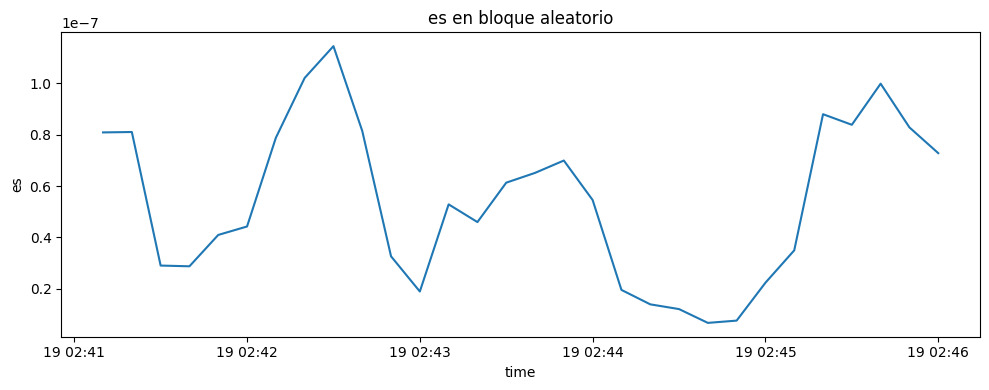

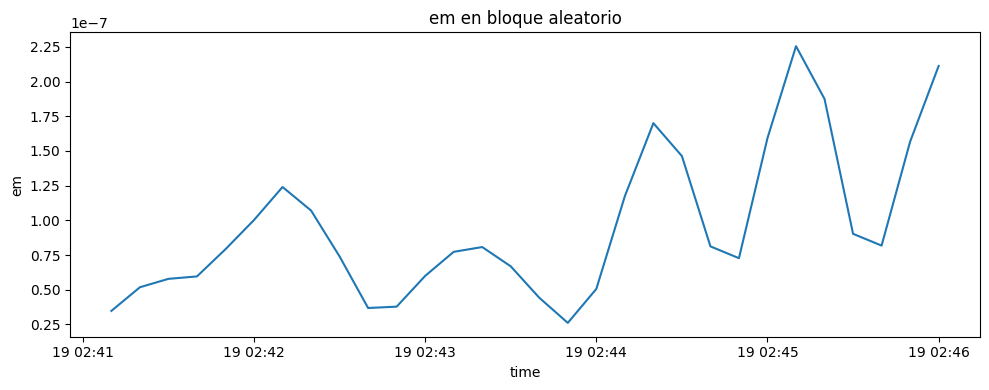

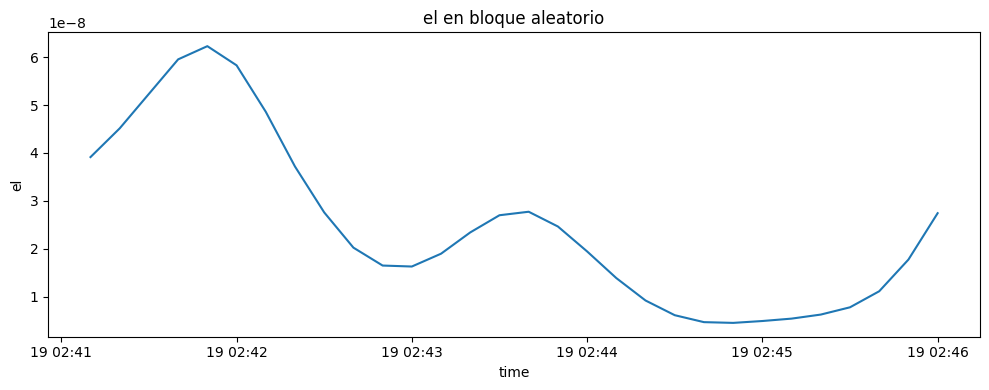

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_e = ["es", "em", "el"]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_e].dropna()

# 3) Graficar es, em y el
for c in cols_e:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[c])
    plt.title(f"{c} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(c)
    plt.tight_layout(); plt.show()


***Energia log-relativa***

In [ ]:
df10["e_total"] = df10["es"] + df10["em"] + df10["el"]
s = df10["e_total"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 0


In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_total"])
df10["erm"] = np.log((df10["em"]) / df10["e_total"])
df10["erl"] = np.log((df10["el"]) / df10["e_total"])

In [ ]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 32 columns):
 #   Column        Dtype         
---  ------        -----         
 0   time          datetime64[ns]
 1   day           int64         
 2   close         float64       
 3   close_ln      float64       
 4   r             float64       
 5   RV_r          float64       
 6   j1            float64       
 7   j2            float64       
 8   j3            float64       
 9   j4            float64       
 10  j5            float64       
 11  j6            float64       
 12  a6            float64       
 13  js1           float64       
 14  js2           float64       
 15  js3           float64       
 16  js4           float64       
 17  js5           float64       
 18  js6           float64       
 19  des           float64       
 20  dem           float64       
 21  del           float64       
 22  de_total      float64       
 23  dvol_wlt      float64       
 2

Bloque elegido:
Inicio: 2024-12-20 11:46:10
Fin   : 2024-12-20 12:16:10


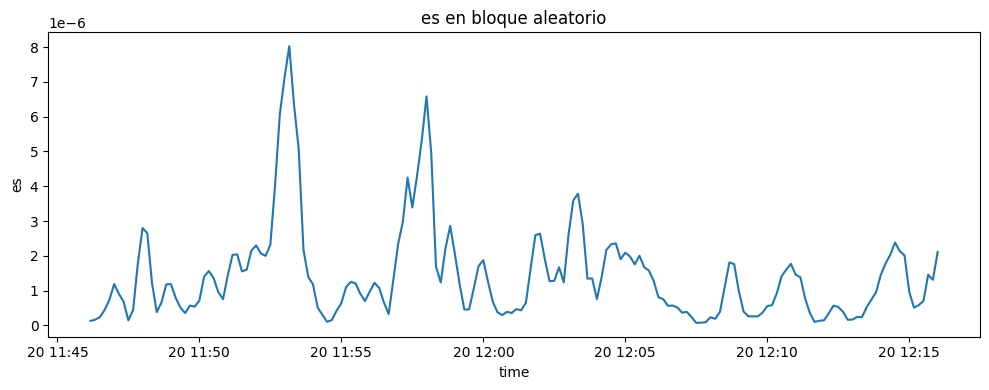

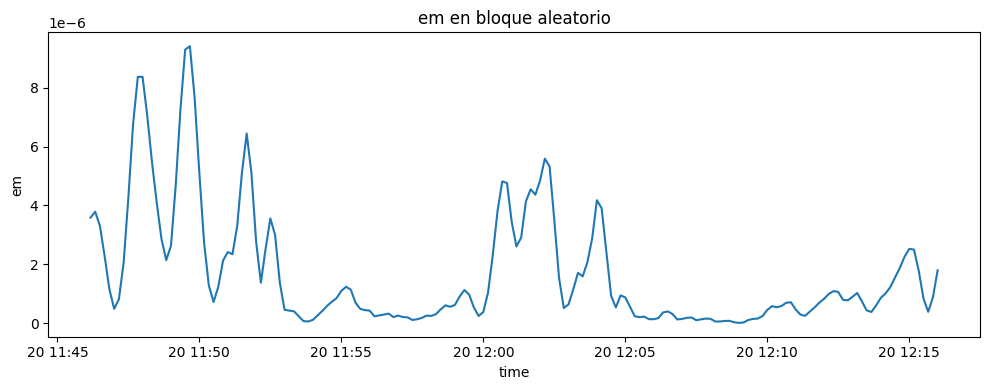

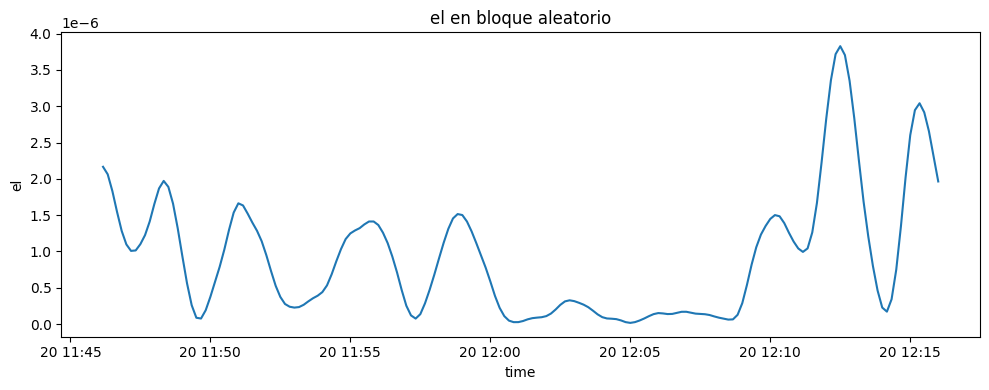

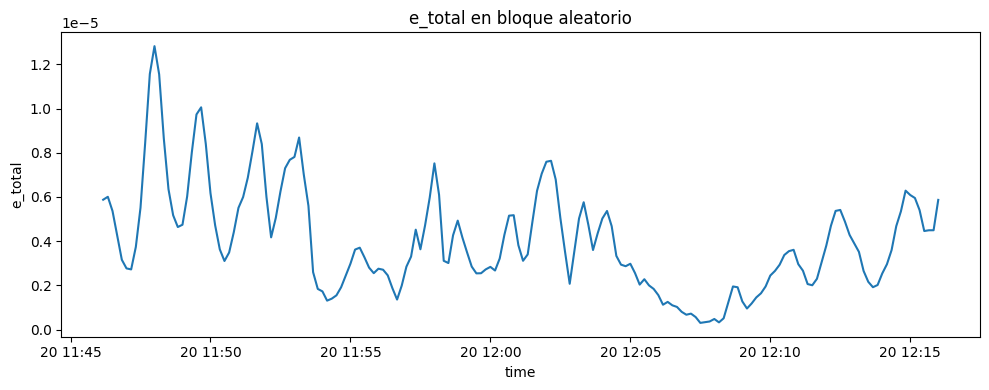

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=30)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_e = ["es", "em", "el", "e_total"]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_e].dropna()

# 3) Graficar es, em, el y e_total
for c in cols_e:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[c])
    plt.title(f"{c} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(c)
    plt.tight_layout(); plt.show()

In [ ]:
df10["vol_wlt"] = np.sqrt(df10["e_total"])

In [ ]:
s = df10["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 0


In [ ]:
df10["log_vol_wlt"] = np.log(df10["vol_wlt"])

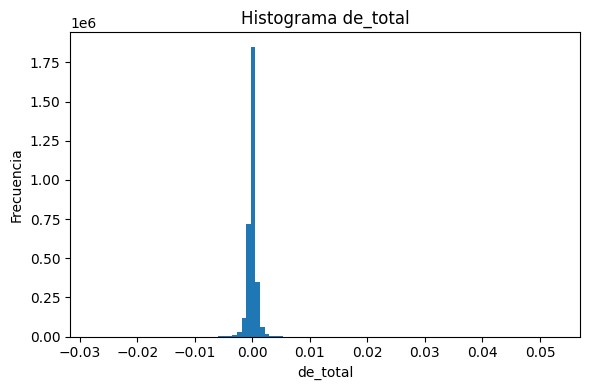

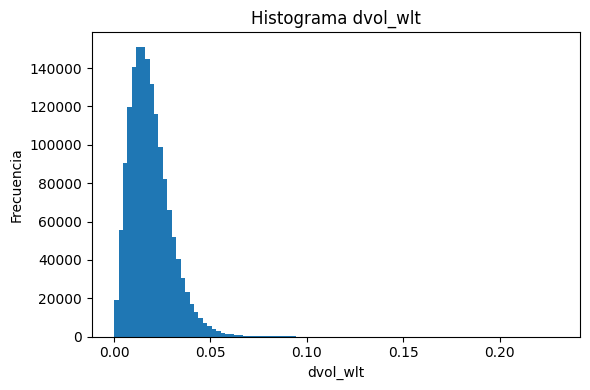

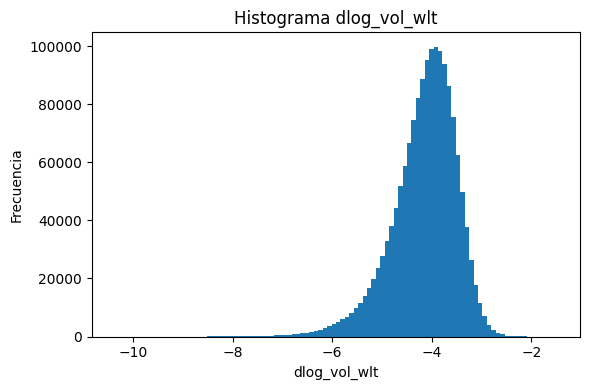

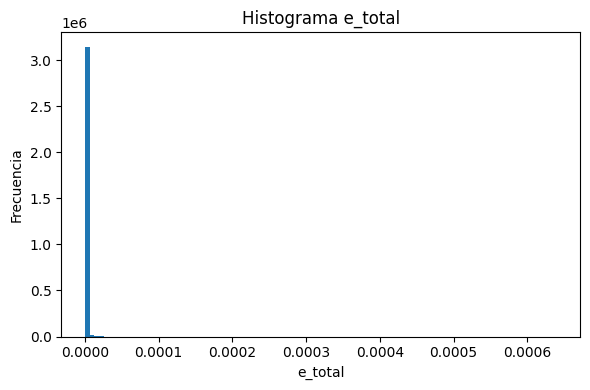

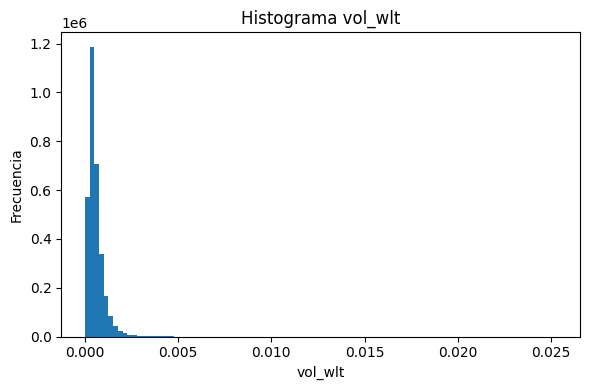

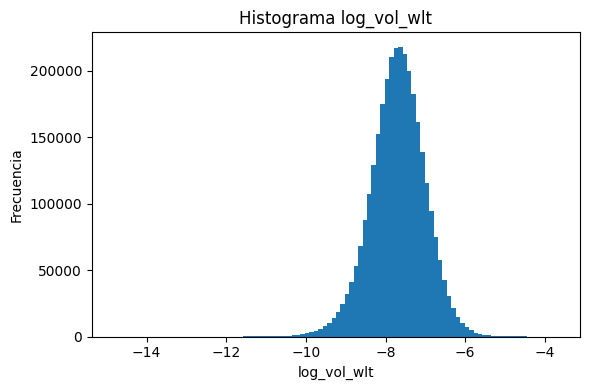

In [ ]:
import matplotlib.pyplot as plt
# Histograma de_total
plt.figure(figsize=(6,4))
plt.hist(df10["de_total"].dropna(), bins=100)
plt.title("Histograma de_total")
plt.xlabel("de_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma dvol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["dvol_wlt"].dropna(), bins=100)
plt.title("Histograma dvol_wlt")
plt.xlabel("dvol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma dlog_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["dlog_vol_wlt"].dropna(), bins=100)
plt.title("Histograma dlog_vol_wlt")
plt.xlabel("dlog_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df10["e_total"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

Individual checks

In [ ]:
import numpy as np
from scipy.stats import skew

s = df15["log_vol_wlt"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)



print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)

Media: -7.6951405930668475
Mediana: -7.6797583615507
Moda: -14.814499408957316
Desvío estándar: 0.6866558271615305
Skew: -0.24768430917128964


In [ ]:
# Moda por bindeo (más representativa)
counts, bins = np.histogram(s, bins=100)
moda_real = bins[np.argmax(counts)]
print("moda bins:", moda_real)

moda bins: -7.686795619731339


Deciles (0.1..0.9): [-8.548225151350989, -8.232745221413321, -8.019208997447066, -7.842356056001769, -7.6797583615507, -7.517218044153186, -7.342826576134334, -7.137836306079423, -6.850075070436032]
Permil 0.005: -9.747002813764164

ACF primeros 20 lags (lag: valor):
 0: 1.000000
 1: 0.985772
 2: 0.957224
 3: 0.926612
 4: 0.902901
 5: 0.884470
 6: 0.867567
 7: 0.853567
 8: 0.842209
 9: 0.834160
10: 0.826791
11: 0.818534
12: 0.809370
13: 0.800697
14: 0.793553
15: 0.788552
16: 0.785715
17: 0.784469
18: 0.783703
19: 0.782373
20: 0.780001


<Figure size 1000x400 with 0 Axes>

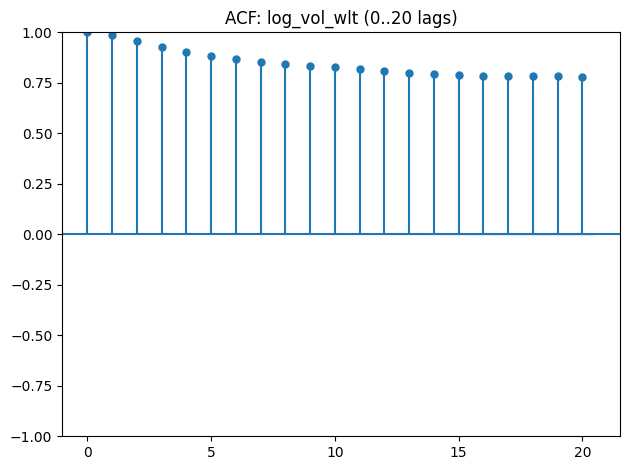


Top 5 días con más obs <= permil 0.005:
day
2024-06-23    1785
2024-06-22    1485
2024-06-09    1289
2024-10-20     923
2024-09-15     581
dtype: int64


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

s = df15["log_vol_wlt"].dropna()

# 1) Deciles + permil 0.005 (0.5%)
deciles = s.quantile(np.arange(0.1, 1.0, 0.1)).tolist()
p0005 = s.quantile(0.005)
print("Deciles (0.1..0.9):", deciles)
print("Permil 0.005:", p0005)

# 2) Autocorrelación: primeros 20 lags + gráfica
acf_vals = acf(s.values, nlags=20, fft=True)  # incluye lag 0
print("\nACF primeros 20 lags (lag: valor):")
for lag, val in enumerate(acf_vals[:21]):
    print(f"{lag:>2}: {val:.6f}")

plt.figure(figsize=(10,4))
plot_acf(s, lags=20, zero=True)
plt.title("ACF: log_vol_wlt (0..20 lags)")
plt.tight_layout()
plt.show()

# 3) Top 5 días con más observaciones <= permil 0.005
d = df15.loc[df15["log_vol_wlt"].le(p0005), ["time"]].dropna()
top5 = (d.assign(day=d["time"].dt.date)
         .groupby("day").size()
         .sort_values(ascending=False)
         .head(5))
print("\nTop 5 días con más obs <= permil 0.005:")
print(top5)

In [ ]:
s = df15["log_vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 0


Realized variance Test

In [ ]:
# Limpieza mínima
s = df15[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.16557027358617013
Spearman: 0.5153190529978882
Kendall : 0.3602789997613362


In [ ]:
# Limpieza mínima
s = df15[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.4228209095367485
Spearman: 0.5153190529978882
Kendall : 0.3602789997613362


In [ ]:
import statsmodels.api as sm

# Datos
y = df15["RV_r"]
X = df15["log_vol_wlt"]

# Limpieza mínima
mask = y.notna() & X.notna()
y = y[mask]
X = X[mask]

# OLS
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Estadísticos clave
print("Coeficientes:")
print(model.params, "\n")

print("R2:", model.rsquared)
print("R2 ajustado:", model.rsquared_adj)
print("F-stat:", model.fvalue)
print("p-value (F):", model.f_pvalue)
print("AIC:", model.aic)
print("BIC:", model.bic)

print("\nResumen completo:")
print(model.summary())

Bloques

In [ ]:
# Asegurar datetime
df15["time"] = pd.to_datetime(df15["time"])

# Setear índice temporal
df15_ = df15.set_index("time")

# Agregación a 15 minutos
df5m = df15_.resample("5T").agg({
    "RV_r": "sum",
    "e_total": "sum",
    "de_total": "sum",
    "log_vol_wlt": "mean",
    "vol_wlt": "mean"
}).reset_index()

df5m.head()

/tmp/ipython-input-3283487202.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df5m = df15_.resample("5T").agg({


,time,RV_r,e_total,de_total,log_vol_wlt,vol_wlt
0,2024-01-01 00:00:00,8.850302e-07,0.000005,-0.007871,-7.897892,0.000380
1,2024-01-01 00:05:00,8.128024e-07,0.000005,0.004274,-7.843989,0.000398
2,2024-01-01 00:10:00,7.139051e-07,0.000007,-0.006213,-7.664547,0.000473
3,2024-01-01 00:15:00,1.040920e-06,0.000007,0.005542,-7.686534,0.000468
4,2024-01-01 00:20:00,4.248116e-07,0.000006,-0.007190,-7.760870,0.000438


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.37199996020079695
Spearman: 0.9353337535127475
Kendall : 0.7874612700169711


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.8774666526779349
Spearman: 0.9189316864022443
Kendall : 0.7635214552776779


In [ ]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 28 columns):
 #   Column       Dtype         
---  ------       -----         
 0   time         datetime64[ns]
 1   day          int64         
 2   close        float64       
 3   close_ln     float64       
 4   r            float64       
 5   RV_r         float64       
 6   j1           float64       
 7   j2           float64       
 8   j3           float64       
 9   j4           float64       
 10  j5           float64       
 11  j6           float64       
 12  a6           float64       
 13  js1          float64       
 14  js2          float64       
 15  js3          float64       
 16  js4          float64       
 17  js5          float64       
 18  js6          float64       
 19  es           float64       
 20  em           float64       
 21  el           float64       
 22  e_total      float64       
 23  ers          float64       
 24  erm          float64   

### fr VPN productiva j=3 *

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.863120          0.136880        0.018851   
1    sym6  3      0.862229          0.137771        0.028615   
2     db6  3      0.862821          0.137179        0.029370   
3    sym4  3      0.862455          0.137545        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        0.980421   788.172962  
1             0.003599        0.976053  1527.291776  
2             0.003750        0.976940  1623.675248  
3             0.003572        0.974309  1625.363930  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.15530536 0.29846131 0.54623333]


In [ ]:
df10["RV_r"] = df10["r"]**2

Energia local suavizada

In [ ]:
import numpy as np
import pandas as pd
import pywt
from scipy.signal import lfilter

def get_modwt_final_boss(df, col, w_name="db4", J=3):
    """
    MODWT Causal con Normalización de Percival & Walden,
    Notación Científica y Validación de Energía Ortogonal.
    """
    # 1. Preparación de datos
    x = df[col].fillna(0.0).values
    n = len(x)

    wavelet = pywt.Wavelet(w_name)
    h_base = wavelet.dec_hi / np.sqrt(2)
    g_base = wavelet.dec_lo / np.sqrt(2)
    L = len(h_base)

    current_a = x
    res_cols = []

    # 2. Descomposición Multinivel Causal
    for j in range(1, J + 1):
        step = 2**(j-1)
        # Dilatación del filtro (Algoritmo à trous)
        h_dil = np.zeros(L + (L - 1) * (step - 1))
        g_dil = np.zeros(L + (L - 1) * (step - 1))
        h_dil[::step] = h_base
        g_dil[::step] = g_base

        # Filtrado LFilter (Causalidad garantizada por Scipy)
        wj = lfilter(h_dil, [1.0], current_a)
        vj = lfilter(g_dil, [1.0], current_a)

        df[f"j{j}"] = wj
        res_cols.append(f"j{j}")
        current_a = vj

    df[f"a{J}"] = current_a
    res_cols.append(f"a{J}")

    # 3. Embargo y Auditoría Científica
    max_warmup = (L - 1) * (2**J - 1)

    # Limpiamos bordes para el test
    clean_df = df.iloc[max_warmup:].copy().dropna()

    if len(clean_df) > 100:
        # Usamos el mismo segmento para X y para los Coeficientes
        x_clean = x[max_warmup:max_warmup + len(clean_df)]

        var_x = np.var(x_clean, ddof=1)
        var_coeffs = clean_df[res_cols].var(ddof=1).sum()

        # Imprimir con precisión científica para evitar el "redondeo a cero"
        print("🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):")
        print(f"   Varianza Original (Var(x)): {var_x:.8e}")
        print(f"   Suma Varianzas (ΣVar):      {var_coeffs:.8e}")

        error_rel = np.abs(var_x - var_coeffs) / var_x if var_x > 0 else 0
        print(f"   Error Relativo:             {error_rel:.4%}")

        # Test de correlación (para demostrar que los niveles capturan info distinta)
        avg_corr = clean_df[res_cols].corr().abs().values[np.triu_indices(len(res_cols), k=1)].mean()
        print(f"   Correlación Media Inter-Nivel: {avg_corr:.4f}")

    # Aplicar NaNs de seguridad en el DataFrame original
    for col_res in res_cols:
        df.loc[df.index[:max_warmup], col_res] = np.nan

    return df

# Ejecución
df10 = get_modwt_final_boss(df10, "r", w_name="db4", J=3)

🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):
   Varianza Original (Var(x)): 8.43195300e-08
   Suma Varianzas (ΣVar):      8.43196235e-08
   Error Relativo:             0.0001%
   Correlación Media Inter-Nivel: 0.0014


In [ ]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 10 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   RV_r      float64       
 6   j1        float64       
 7   j2        float64       
 8   j3        float64       
 9   a3        float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 241.3 MB


In [ ]:
for j in range(1, 4):
    c = df10[f"j{j}"]
    df10[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

In [ ]:
df10["es"] = df10["js1"]
df10["em"] = df10["js2"]
df10["el"] = df10["js3"]

In [ ]:
df10["e_d"] = df10["es"] + df10["em"] + df10["el"]
s = df10["e_d"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 49


In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_d"])
df10["erm"] = np.log((df10["em"]) / df10["e_d"])
df10["erl"] = np.log((df10["el"]) / df10["e_d"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["vol_wlt"] = np.sqrt(df10["e_d"])

In [ ]:
s = df10["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 49


In [ ]:
df10["log_vol_wlt"] = np.log(df10["vol_wlt"])

In [ ]:
df10["as3"] = (df10["a3"] * df10["a3"]).rolling(3, min_periods=1).mean()
df10["e_total"] = df10["es"] + df10["em"] + df10["el"] + df10["as3"]

In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_total"])
df10["erm"] = np.log((df10["em"]) / df10["e_total"])
df10["erl"] = np.log((df10["el"]) / df10["e_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["tvol_wlt"] = np.sqrt(df10["e_total"])

In [ ]:
s = df10["tvol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 49


In [ ]:
df10["tlog_vol_wlt"] = np.log(df10["tvol_wlt"])

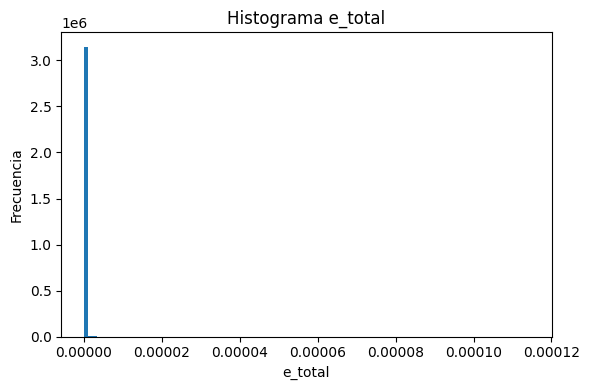

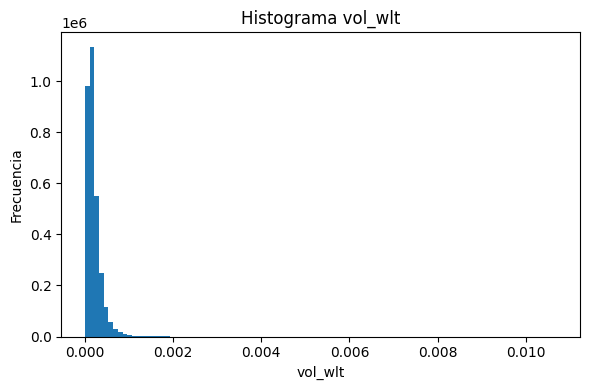

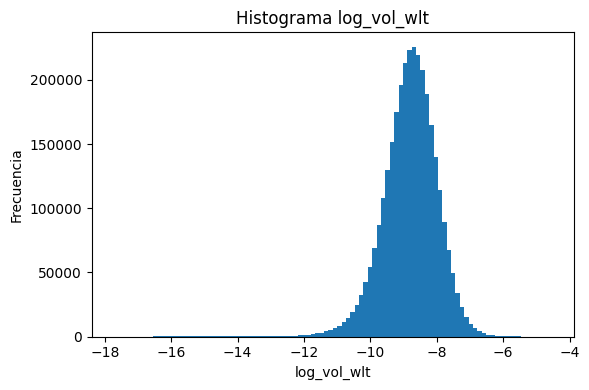

In [ ]:
import matplotlib.pyplot as plt

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df10["e_d"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-08-22 20:38:40
Fin   : 2024-08-22 20:43:40


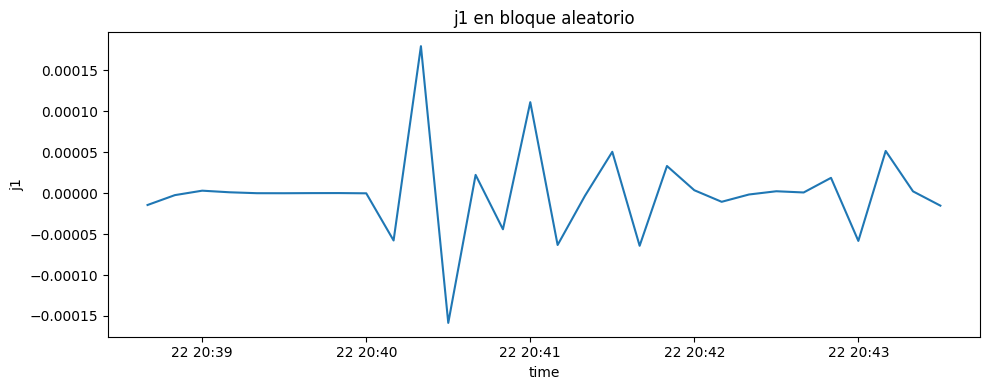

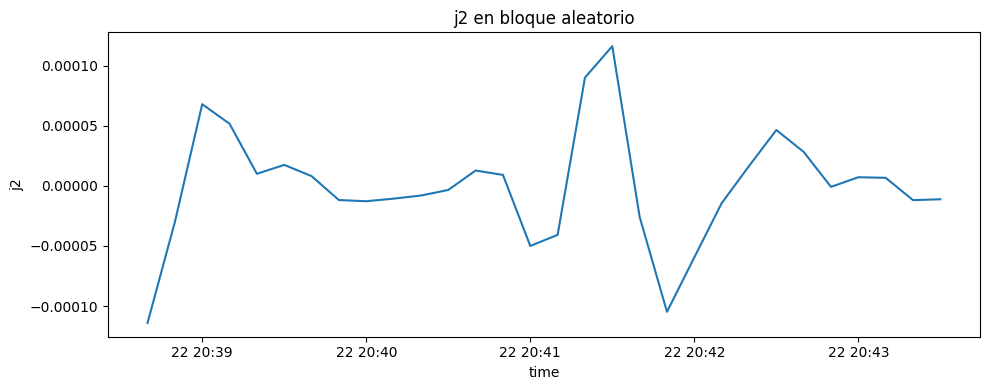

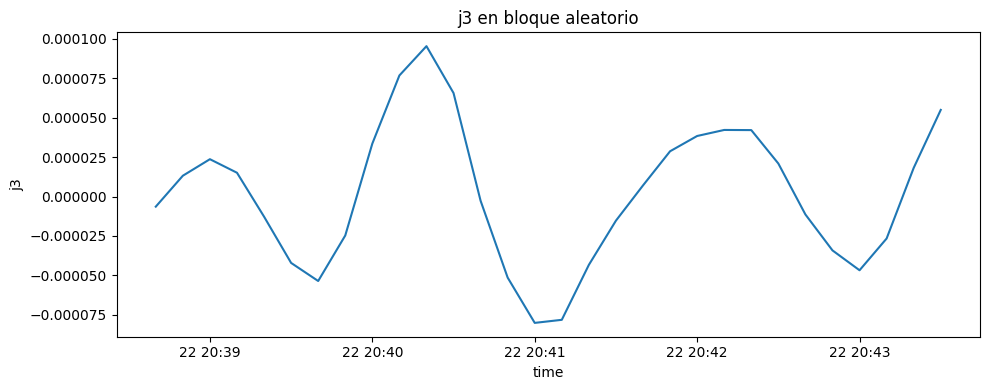

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 4)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-11-19 13:01:46
Fin   : 2024-11-19 13:06:46


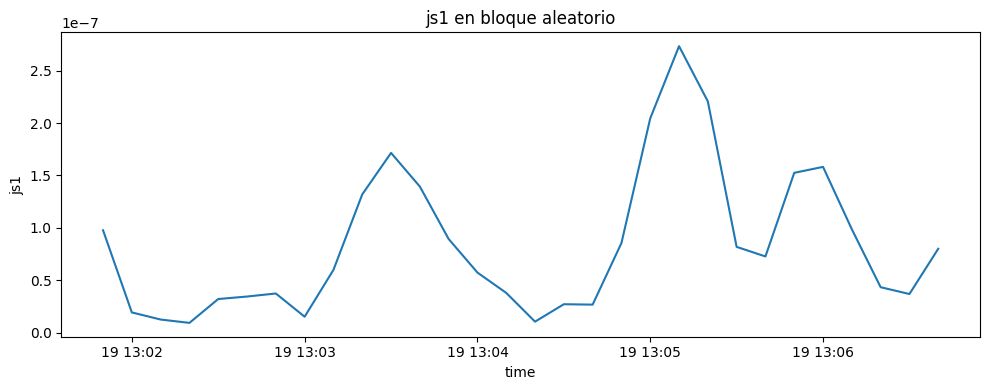

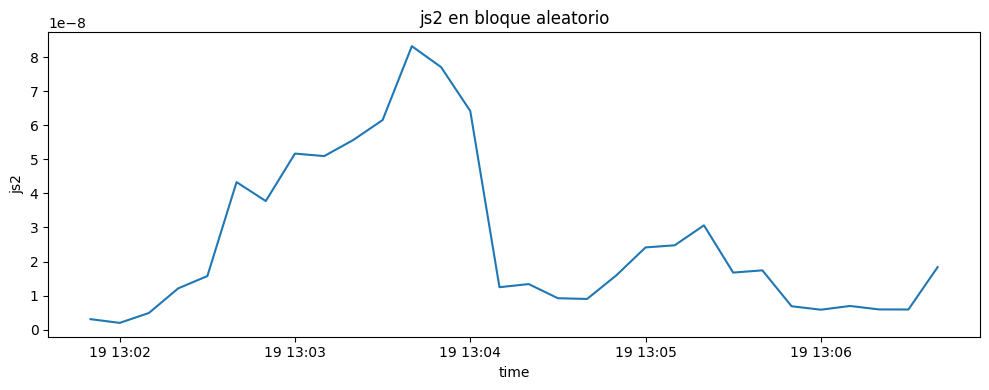

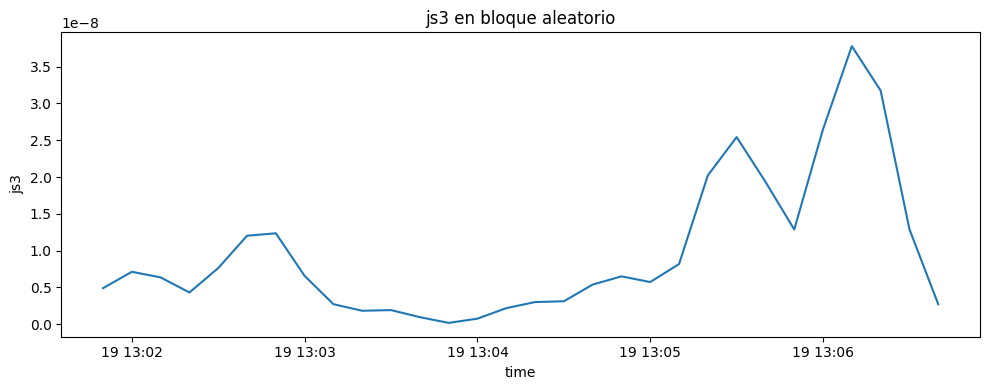

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 4)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()

*Eshort, Emedium and ELong all RAW*

In [ ]:
df10["des"] = df10["j1"]
df10["dem"] = df10["j2"]
df10["del"] = df10["j3"]

In [ ]:
s = df10["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df10["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df10["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 878
des Nulls: 49
dem Ceros: 0
dem Nulls: 49
del Ceros: 0
del Nulls: 49


In [ ]:
df10["de_total"] = df10["des"] + df10["dem"] + df10["del"]

In [ ]:
df10["dvol_wlt"] = np.sqrt(df10["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["dlog_vol_wlt"] = np.log(df10["dvol_wlt"])

***Signature Plot***

/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()


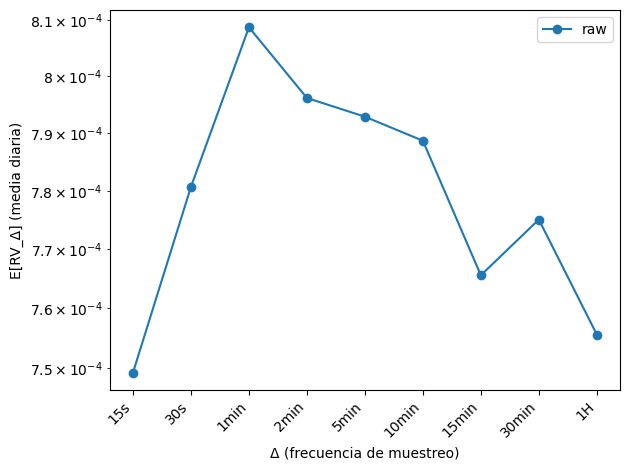

In [ ]:
  #signature plot estandar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def signature_rv_15s(
    df,
    t="time",
    logp="close_ln",
    deltas=("15s","30s","1min","2min","5min","10min","15min","30min","1H")
):
    x = df[[t, logp]].dropna().copy()
    x = x.sort_values(t).set_index(t)

    out = []
    for d in deltas:
        lp = x[logp].resample(d).last().dropna()
        r  = lp.diff().dropna()

        rv_block = r.pow(2).groupby(r.index.floor("D")).sum()
        out.append((d, rv_block.mean(), rv_block.median(), rv_block.size))

    return pd.DataFrame(out, columns=["delta","RV_mean","RV_median","n_days"])


sig_raw = signature_rv_15s(df10)

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ] (media diaria)")
ax.set_xlabel("Δ (frecuencia de muestreo)")
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()
/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()


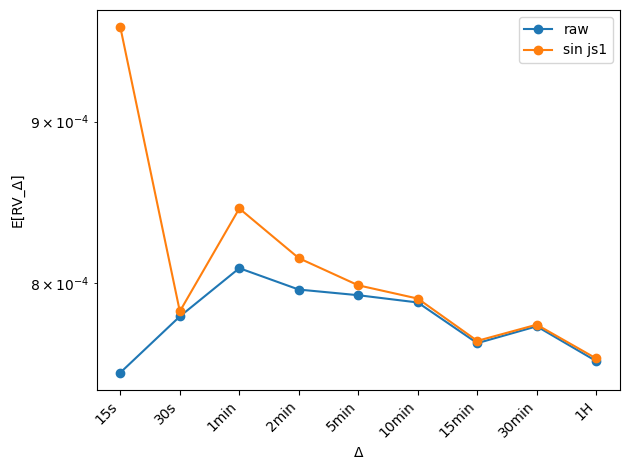

In [ ]:
def add_clean_logprice_15s(
    df,
    t="time",
    logp="close_ln",
    r="r",
    j1="j1",
    out="close_ln_clean"
):
    x = df[[t, logp, r, j1]].dropna().copy()
    x = x.sort_values(t)

    r_clean = (x[r] - x[j1]).to_numpy()
    x[out] = x[logp].iloc[0] + np.cumsum(r_clean)

    return x


df15_clean = add_clean_logprice_15s(df10)

sig_raw   = signature_rv_15s(df15_clean, logp="close_ln")
sig_clean = signature_rv_15s(df15_clean, logp="close_ln_clean")

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.plot(sig_clean["RV_mean"].to_numpy(), marker="o", label="sin js1")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ]")
ax.set_xlabel("Δ")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def explosion_score(sig, k=5):
    y = np.log(sig["RV_mean"].to_numpy())
    x = np.log(np.arange(1, len(y) + 1))
    return (y[k] - y[0]) / (x[k] - x[0])

score_raw   = explosion_score(sig_raw)
score_clean = explosion_score(sig_clean)

score_raw, score_clean

(np.float64(0.02858545655243811), np.float64(-0.11057700345805258))

####SHAP

**1 min**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1 min = 6 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 6 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 6 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=6, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=6, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 7 | Test[527037:1054067]
   Fold 2: Train[49:1054061] | Gap: 7 | Test[1054068:1581098]
   Fold 3: Train[49:1581092] | Gap: 7 | Test[1581099:2108129]
   Fold 4: Train[49:2108123] | Gap: 7 | Test[2108130:2635160]
   Fold 5: Train[49:2635154] | Gap: 7 | Test[2635161:3162191]


In [ ]:
horizon = 6
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.602833  0.217362  0.466221  0.361399  0.610131  527022
1     2  0.646733  0.308256  0.555208  0.409706  0.657711  527022
2     3  0.611405  0.213361  0.461910  0.357258  0.612767  527022
3     4  0.637971  0.244146  0.494112  0.374735  0.640682  527022
4     5  0.594061  0.200768  0.448072  0.348750  0.596056  527022

PROMEDIO:
R2      0.618601
MSE     0.236779
RMSE    0.485105
MAE     0.370369
EVS     0.623469
dtype: float64


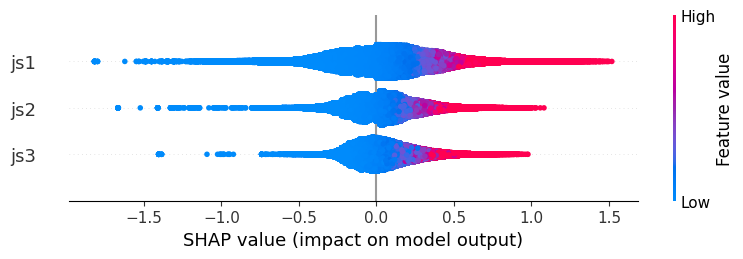

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**1 min navie**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.583386  0.228005  0.477499  0.370602  0.593654  527022
1     2  0.599950  0.349078  0.590829  0.422588  0.613252  527022
2     3  0.595198  0.222260  0.471444  0.364839  0.597902  527022
3     4  0.613553  0.260614  0.510504  0.385150  0.616262  527022
4     5  0.576158  0.209622  0.457845  0.356546  0.580161  527022

PROMEDIO:
R2      0.593649
MSE     0.253916
RMSE    0.501624
MAE     0.379945
EVS     0.600246
dtype: float64


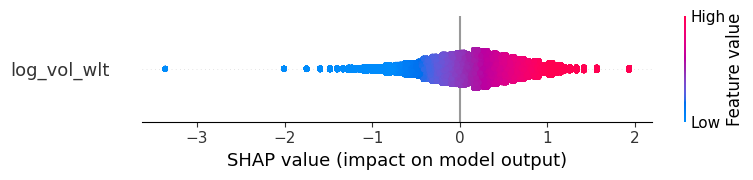

In [ ]:

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE

 #NAVIE                            #NAVIE                              #NAVIE

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#

import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd


class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["log_vol_wlt"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)




```
# Esto tiene formato de código
```

**1 min navie +shifted(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.562103  0.239653  0.489543  0.380756  0.573569  527022
1     2  0.577736  0.368462  0.607011  0.435805  0.592650  527022
2     3  0.575461  0.233098  0.482802  0.374393  0.578514  527022
3     4  0.592881  0.274554  0.523979  0.396610  0.595916  527022
4     5  0.555691  0.219745  0.468770  0.365652  0.560182  527022

PROMEDIO:
R2      0.572774
MSE     0.267102
RMSE    0.514421
MAE     0.390643
EVS     0.580166
dtype: float64


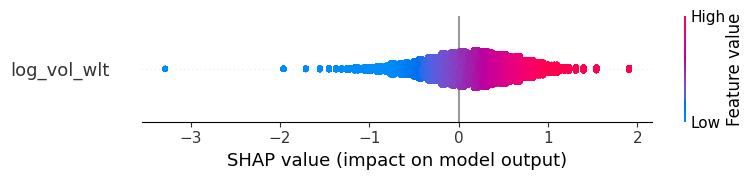

In [ ]:

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE

 #NAVIE                            #NAVIE                              #NAVIE

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#

import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd


class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["log_vol_wlt"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49
# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

**1 min + Shift(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.579566  0.230095  0.479683  0.372951  0.588125  527022
1     2  0.621642  0.330150  0.574586  0.424404  0.634267  527022
2     3  0.589996  0.225117  0.474465  0.367993  0.591617  527022
3     4  0.615366  0.259390  0.509304  0.387249  0.618405  527022
4     5  0.571681  0.211837  0.460258  0.359030  0.574026  527022

PROMEDIO:
R2      0.595650
MSE     0.251318
RMSE    0.499659
MAE     0.382325
EVS     0.601288
dtype: float64


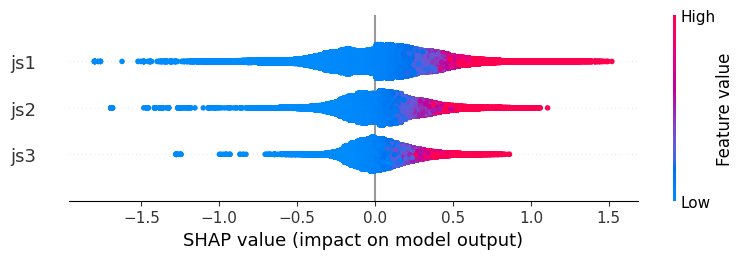

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49  # 6*10s = 1 min

# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**HF**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1/6 min = 1 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 1 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 1 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=1, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 1/6 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=1, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 2 | Test[527032:1054062]
   Fold 2: Train[49:1054061] | Gap: 2 | Test[1054063:1581093]
   Fold 3: Train[49:1581092] | Gap: 2 | Test[1581094:2108124]
   Fold 4: Train[49:2108123] | Gap: 2 | Test[2108125:2635155]
   Fold 5: Train[49:2635154] | Gap: 2 | Test[2635156:3162186]


In [ ]:
horizon = 1
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.814572  0.101481  0.318560  0.246697  0.815218  527023
1     2  0.851441  0.129633  0.360046  0.267857  0.853034  527023
2     3  0.814612  0.101786  0.319038  0.246578  0.814680  527023
3     4  0.836026  0.110584  0.332541  0.254370  0.836510  527023
4     5  0.802099  0.097876  0.312852  0.242405  0.802151  527023

PROMEDIO:
R2      0.823750
MSE     0.108272
RMSE    0.328608
MAE     0.251581
EVS     0.824319
dtype: float64


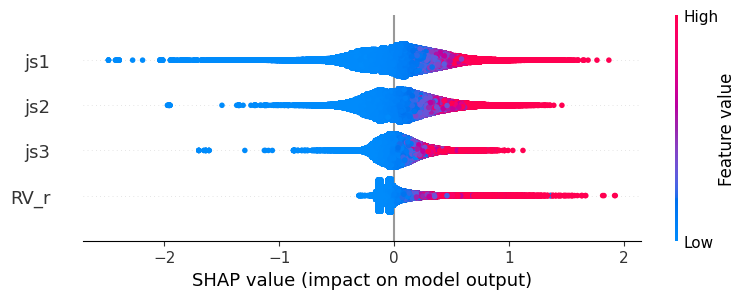

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3","RV_r"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.773240  0.124101  0.352279  0.269738  0.774945  527023
1     2  0.809565  0.166174  0.407644  0.298799  0.812447  527023
2     3  0.774529  0.123793  0.351842  0.269233  0.774775  527023
3     4  0.796733  0.137083  0.370247  0.279619  0.797528  527023
4     5  0.761888  0.117763  0.343167  0.263805  0.762283  527023

PROMEDIO:
R2      0.783191
MSE     0.133783
RMSE    0.365036
MAE     0.276239
EVS     0.784396
dtype: float64


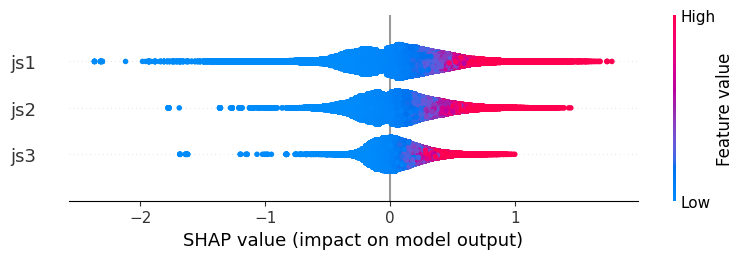

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

**10 segs + Shift(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.672049  0.179480  0.423651  0.328483  0.676240  527023
1     2  0.724269  0.240603  0.490513  0.365421  0.730650  527023
2     3  0.675613  0.178102  0.422021  0.326740  0.676291  527023
3     4  0.705841  0.198380  0.445399  0.340075  0.707680  527023
4     5  0.658663  0.168816  0.410873  0.319779  0.659730  527023

PROMEDIO:
R2      0.687287
MSE     0.193076
RMSE    0.438491
MAE     0.336100
EVS     0.690118
dtype: float64


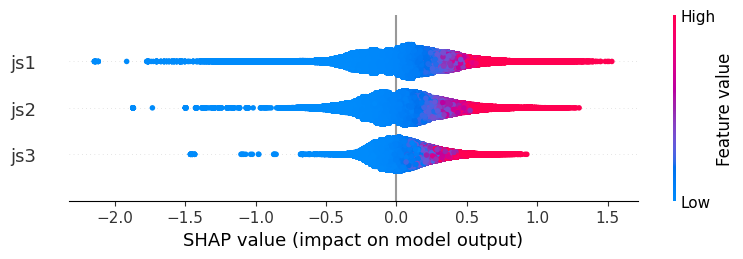

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49  # 6*10s = 1 min

# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**2 min**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 2 min = 12 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 12 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 12 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=12, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=12, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 13 | Test[527043:1054073]
   Fold 2: Train[49:1054061] | Gap: 13 | Test[1054074:1581104]
   Fold 3: Train[49:1581092] | Gap: 13 | Test[1581105:2108135]
   Fold 4: Train[49:2108123] | Gap: 13 | Test[2108136:2635166]
   Fold 5: Train[49:2635154] | Gap: 13 | Test[2635167:3162197]


In [ ]:
horizon = 12
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.485294  0.281690  0.530745  0.414707  0.499266  527021
1     2  0.499133  0.437042  0.661091  0.480747  0.520387  527021
2     3  0.500285  0.274400  0.523832  0.407174  0.503656  527021
3     4  0.511704  0.329283  0.573832  0.434338  0.516438  527021
4     5  0.483764  0.255319  0.505291  0.395159  0.488626  527021

PROMEDIO:
R2      0.496036
MSE     0.315547
RMSE    0.558958
MAE     0.426425
EVS     0.505675
dtype: float64


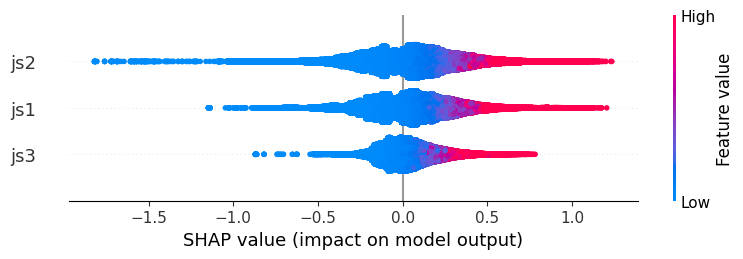

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 12, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**5 min**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 5 min = 30 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 30 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 30 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=30, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 5 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=30, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 31 | Test[527061:1054091]
   Fold 2: Train[49:1054061] | Gap: 31 | Test[1054092:1581122]
   Fold 3: Train[49:1581092] | Gap: 31 | Test[1581123:2108153]
   Fold 4: Train[49:2108123] | Gap: 31 | Test[2108154:2635184]
   Fold 5: Train[49:2635154] | Gap: 31 | Test[2635185:3162215]


In [ ]:
horizon = 30
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.419182  0.317875  0.563804  0.440681  0.437899  527018
1     2  0.360311  0.558145  0.747091  0.522204  0.398144  527018
2     3  0.430153  0.312997  0.559461  0.433516  0.434810  527018
3     4  0.419479  0.391417  0.625633  0.464399  0.427726  527018
4     5  0.427119  0.283336  0.532293  0.415484  0.432294  527018

PROMEDIO:
R2      0.411249
MSE     0.372754
RMSE    0.605657
MAE     0.455257
EVS     0.426175
dtype: float64


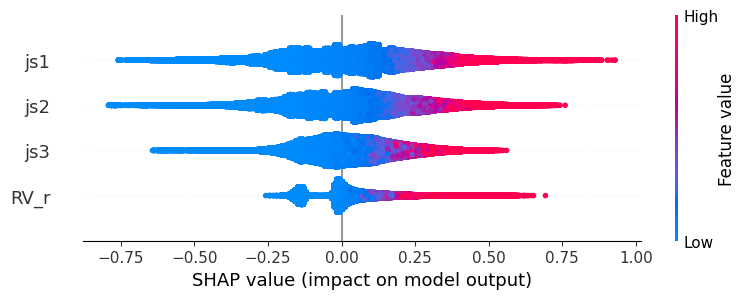

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3","RV_r"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 30, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


In [ ]:
# TOP HORIZONTES
# 1 MINUTO *
# 2 MINUTOS

#### SHAP REGIMENES

**1 minuto**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1 min = 6 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_min = 6

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 6 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=6, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=6, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 7 | Test[527037:1054067]
   Fold 2: Train[49:1054061] | Gap: 7 | Test[1054068:1581098]
   Fold 3: Train[49:1581092] | Gap: 7 | Test[1581099:2108129]
   Fold 4: Train[49:2108123] | Gap: 7 | Test[2108130:2635160]
   Fold 5: Train[49:2635154] | Gap: 7 | Test[2635161:3162191]


In [ ]:
horizon = 6
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.602842  0.217357  0.466215  0.361394  0.610139  527022
1     2  0.646709  0.308263  0.555214  0.409714  0.657688  527022
2     3  0.611528  0.213367  0.461917  0.357262  0.612888  527022
3     4  0.637907  0.244141  0.494107  0.374731  0.640616  527022
4     5  0.594069  0.200765  0.448068  0.348748  0.596064  527022

PROMEDIO:
R2      0.618611
MSE     0.236779
RMSE    0.485104
MAE     0.370370
EVS     0.623479
dtype: float64


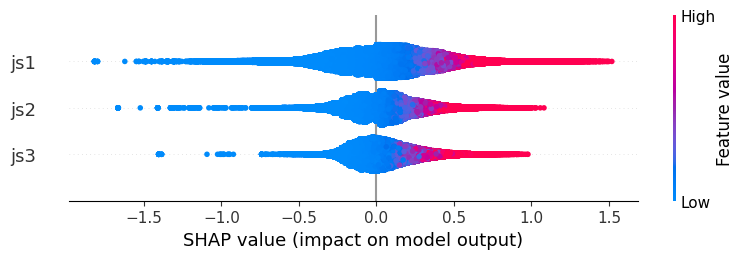

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 30, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]
# shift causal de features
df10[features] = df10[features].shift(1)

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


/tmp/ipython-input-3688304185.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  regime_metrics = analysis.groupby('Regime', observed=True).apply(lambda x: pd.Series({
/tmp/ipython-input-3688304185.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Regime', y='Error', data=analysis, palette='viridis')


📊 MÉTRICAS POR RÉGIMEN DE VOLATILIDAD:
                  R2       MAE      Bias     Count
Regime                                            
Baja        0.285934  0.406448 -0.020117  105405.0
Media-Baja  0.117349  0.352722 -0.027704  105404.0
Media       0.090794  0.338125 -0.035111  105404.0
Media-Alta  0.095340  0.327914 -0.038575  105404.0
Alta        0.261895  0.318532 -0.035568  105405.0


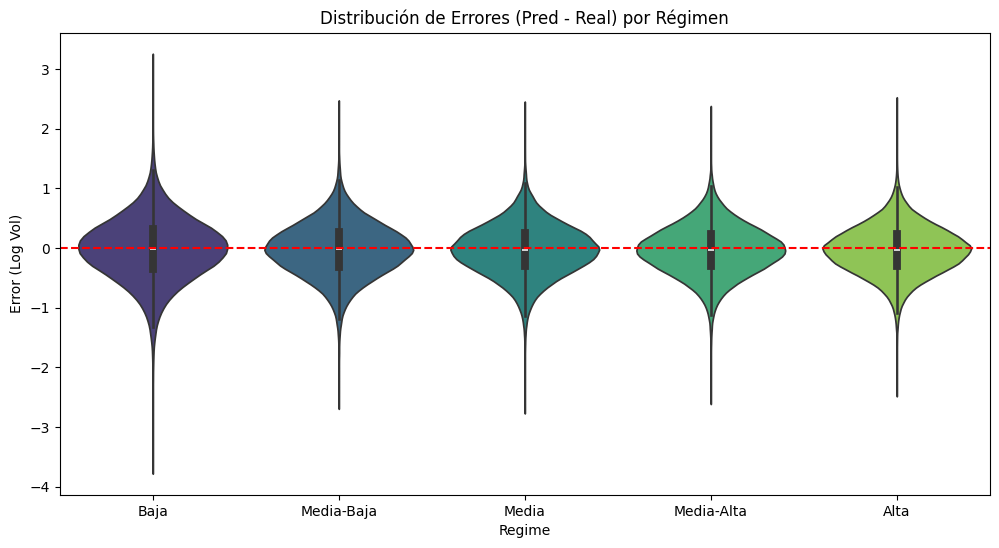

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperamos la volatilidad actual para el último fold de test
# Asumimos que 'log_vol_now' está alineada con 'last_Xte'
vol_now_test = df10.loc[last_Xte.index, "log_vol_wlt"]

# 2. Creamos los 5 regímenes basados en quintiles
regime_labels = ['Baja', 'Media-Baja', 'Media', 'Media-Alta', 'Alta']
regimes = pd.qcut(vol_now_test, 5, labels=regime_labels)

# 3. Construimos el DataFrame de análisis de residuos
analysis = pd.DataFrame({
    'Real': last_yte,
    'Pred': last_model.predict(last_Xte),
    'Regime': regimes
})
analysis['Error'] = analysis['Pred'] - analysis['Real']
analysis['AbsError'] = analysis['Error'].abs()

# 4. Cálculo de métricas por régimen
regime_metrics = analysis.groupby('Regime', observed=True).apply(lambda x: pd.Series({
    'R2': r2_score(x['Real'], x['Pred']),
    'MAE': x['AbsError'].mean(),
    'Bias': x['Error'].mean(),
    'Count': len(x)
}))

print("📊 MÉTRICAS POR RÉGIMEN DE VOLATILIDAD:")
print(regime_metrics)

# 5. Visualización de la "Firma del Error"
plt.figure(figsize=(12, 6))
sns.violinplot(x='Regime', y='Error', data=analysis, palette='viridis')
plt.axhline(0, color='red', linestyle='--')
plt.title('Distribución de Errores (Pred - Real) por Régimen')
plt.ylabel('Error (Log Vol)')
plt.show()

In [ ]:
# el modelo es mas preciso en los extremos, el R2 no es importante por la microvarianza inherente al experimento
# Posibles complementos
# 1. modelo truncado
# 2. Wavelet mas larga Js


# complemento indispensable:
# rolling explosition score from signature plot, a 1 hora, 2 horas, o algo asi

####Blocks minutes

15 minutes

In [ ]:
import numpy as np
import pandas as pd

df10["time"] = pd.to_datetime(df10["time"])
df_ = df10.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("15T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-1741640544.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("15T").mean()
/tmp/ipython-input-1741640544.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [ ]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.9223944872133529
Spearman: 0.9728770194837482
Kendall : 0.8642381953500718


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.9728770194837482
Kendall : 0.8642381953500718


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


5 minutes

In [ ]:
import numpy as np
import pandas as pd

df10["time"] = pd.to_datetime(df10["time"])
df_ = df10.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("5T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-1207572129.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("5T").mean()
/tmp/ipython-input-1207572129.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [ ]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.9133079979737936
Spearman: 0.969115585222217
Kendall : 0.8545449970438539


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.969115585222217
Kendall : 0.8545449970438539


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


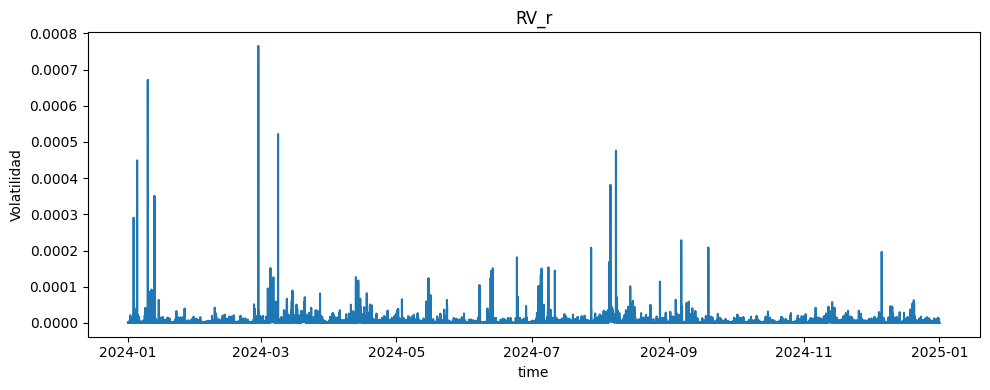

In [ ]:
s = df15m["RV_r"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("RV_r")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

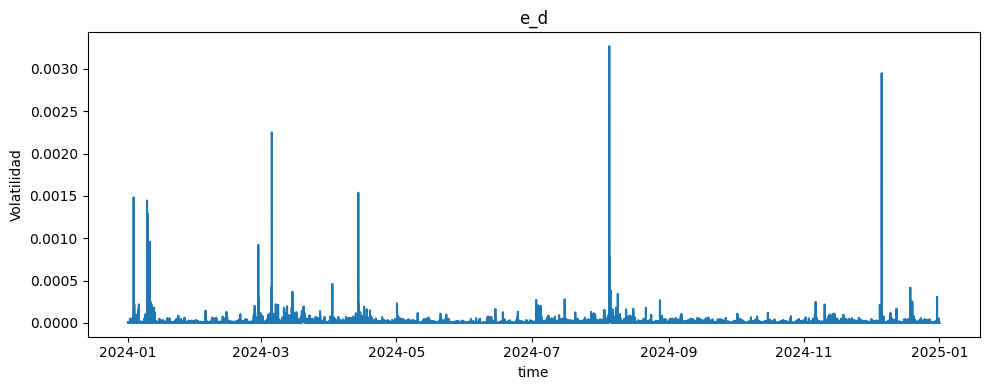

In [ ]:
s = df15m["e_d"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("e_d")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

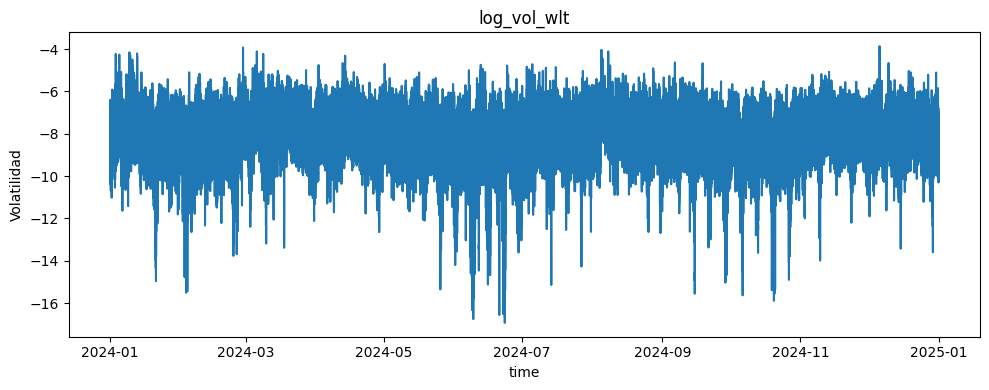

In [ ]:
s = df15["log_vol_wlt"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15.loc[s.index, "time"], s.values)
plt.title("log_vol_wlt")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

***Test iniciales***

In [ ]:
import pandas as pd

x = df15m["vol_wlt"]
r = df15m["r"]

corr_t   = x.corr(r)
corr_tp1 = x.corr(r.shift(-1))

corr_t, corr_tp1

(np.float64(0.009346382080625977), np.float64(0.0037274259736032457))

In [ ]:
#no hay leakage

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lags = [5, 10, 20]

lb_js = {
    f"js{i}": acorr_ljungbox(df15m[f"js{i}"].dropna(), lags=lags, return_df=True)
    for i in [1, 2, 3]
}

lb_js

{'js1':          lb_stat  lb_pvalue
 5   54999.562312        0.0
 10  73851.169901        0.0
 20  92422.459761        0.0,
 'js2':          lb_stat  lb_pvalue
 5   49174.384471        0.0
 10  62040.193222        0.0
 20  74858.937948        0.0,
 'js3':          lb_stat  lb_pvalue
 5   35530.265008        0.0
 10  44092.392903        0.0
 20  51618.090716        0.0}

In [ ]:
#La volatilidad wavelet no es un artefacto de microestructura.
# POR LO TANTO; la vairable no es una varianza fisica sino es un estado latente de intensidad

In [ ]:
import numpy as np

targets = df15m["RV_r"]

corr_levels = {
    "js1": df15m["js1"].corr(targets),
    "js2": df15m["js2"].corr(targets),
    "js3": df15m["js3"].corr(targets),
}

corr_levels

{'js1': np.float64(0.4119542112895267),
 'js2': np.float64(0.4066213093031348),
 'js3': np.float64(0.4400764387086965)}

In [ ]:
#La señal es multiescala, no un truco de j1, por lo cual no es imprecindible

In [ ]:
vol_23 = np.sqrt(df15m["js2"]**2 + df15m["js3"]**2)
vol_23 = np.log(vol_23.replace(0, np.nan))

vol_23.corr(targets)

np.float64(0.2973378807779419)

In [ ]:
#Spearman alto es legítimo, no inflado artificialmente.

In [ ]:
# CONCLUSION
# Si la querés target en un GAT, hacelo ordinal (bins) y entrená para:

# alta Kendall/Spearman out-of-sample,

# estabilidad rolling,

# y consistencia de edges en ventanas.

# La versión “continua con MSE” es posible, pero es pelearte con la geometría equivocada: como medir temperatura con una regla.

# Si me decís cuántos activos y qué frecuencia (5m / 15m), te propongo la definición mínima de:

# nodos/features,

# edges (qué medida usar),

# y el head ordinal (K y thresholds) para que quede coherente con tu proxy.

## r_15 *


In [13]:
df15 = btc.iloc[:, [0, 1, 5, 12]]
df15 = df15.iloc[::15].copy()
df15["r"] = df15["close_ln"].diff()
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 80.4 MB


Media: 3.76809916230909e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.00036078789699599685
Skew: -0.5918241943710671
Deciles:
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
d5 : 0.0
d6 : 2.3319833459822805e-07
d7 : 8.111270573536418e-05
d8 : 0.00017403621973635124
d9 : 0.0003386397390165995
Percentiles mas altos:
d95 : 0.000516697122034948
d96 : 0.0005783330969144623
d97 : 0.0006613860042640953
d98 : 0.0007849116275486496
d99 : 0.00102082375687722
d100 : 0.019740671452751712
Permiles
p970 : 0.0006613860042640953
p971 : 0.0006712843939121873
p972 : 0.0006818457931035193
p973 : 0.0006923294869505018
p974 : 0.0007035229648896201
p975 : 0.000715536563801589
p976 : 0.0007285188955464288
p977 : 0.0007417317042810429
p978 : 0.0007551259786533746
p979 : 0.0007697478319800725
p980 : 0.0007849116275486496
p981 : 0.0008006253623015165
p982 : 0.0008188651597057585
p983 : 0.0008375312170303781
p984 : 0.0008576397359220929
p985 : 0.000

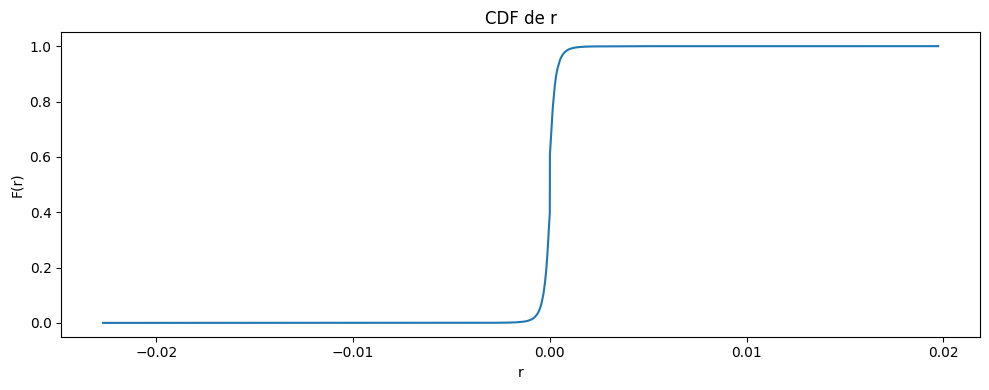

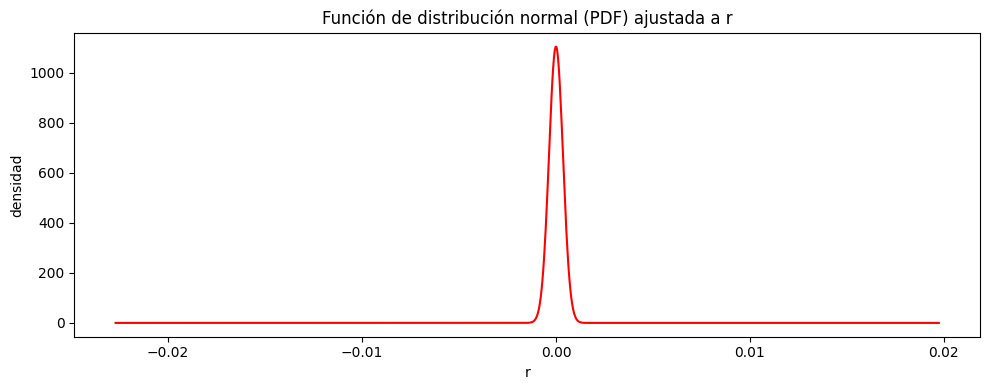

In [14]:
import numpy as np
from scipy.stats import skew, norm

s = df15["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df15["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [15]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.1040912948216904
P0 (eps): 0.1040912948216904
d0 : -0.02270720738637877
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
Percentiles mas bajos:
d0 : -0.0010524389561297482
d1 : -0.000798699366188714
d2 : -0.000668114432760035
d3 : -0.000582131826901005
d4 : -0.0005192846253105614
d5 : -0.00047030662868812807
d6 : -0.0004299274431113105
d7 : -0.00039582443766040143
d8 : -0.0003657379544529
d9 : -0.0003397565633194226
d10 : -0.0003161667496839229
d11 : -0.0002952106950851245
d12 : -0.00027621478841250634
d13 : -0.0002581737193119658
d14 : -0.00024143300978510143
d15 : -0.00022618347367818356
d16 : -0.0002116719089413621
d17 : -0.00019894742109004683
d18 : -0.00018618756073452404
d19 : -0.00017440182492616427


In [16]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.867754          0.132246        0.010111   
1    sym6  3      0.867436          0.132564        0.027775   
2    sym4  3      0.867674          0.132326        0.029308   
3     db6  3      0.867601          0.132399        0.030858   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003614        0.969032   430.287597  
1             0.004873        0.963715  1241.829204  
2             0.004746        0.961043  1270.757320  
3             0.005486        0.960648  1573.084635  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.03457333 0.07175279 0.13179832]
Shares por nivel (J...1):
[0.14519017 0.30132476 0.55348506]


In [17]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.984283          0.015717        0.010111   
1    sym6  6      0.984193          0.015807        0.027775   
2    sym4  6      0.984177          0.015823        0.029308   
3     db6  6      0.984326          0.015674        0.030858   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003614        1.330457   430.287597  
1             0.004873        1.326638  1241.829204  
2             0.004746        1.323769  1270.757320  
3             0.005486        1.324153  1573.084635  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.0044936  0.0090157  0.01846812 0.03457333 0.07175279 0.13179832]
Shares por nivel (J...1):
[0.0166367  0.03337887 0.06837465 0.12800108 0.26565086 0.48795784]


###vnp teorica *************

In [19]:
df15["RV_r"] = df15["r"]**2

Energia local suavizada

In [ ]:
import numpy as np, pywt

x = df10["r"].to_numpy(dtype=float)
x = np.nan_to_num(x, nan=0.0)  # si tenés NaN, swt revienta; mejor imputación simple

J = 6
w = "db4"
n = x.size
m = 1 << J
pad = (-n) % m
xp = np.pad(x, (0, pad), mode="edge") if pad else x

coeffs = pywt.swt(xp, w, level=J, trim_approx=False)

# Detalles por nivel
for j in range(1, J + 1):
    df10[f"j{j}"] = coeffs[J - j][1][:n]   # cDj
df10[f"a{J}"] = coeffs[-1][0][:n]          # cAJ

In [ ]:
df10.info()

Bloque elegido:
Inicio: 2024-06-14 06:44:13
Fin   : 2024-06-14 06:49:13


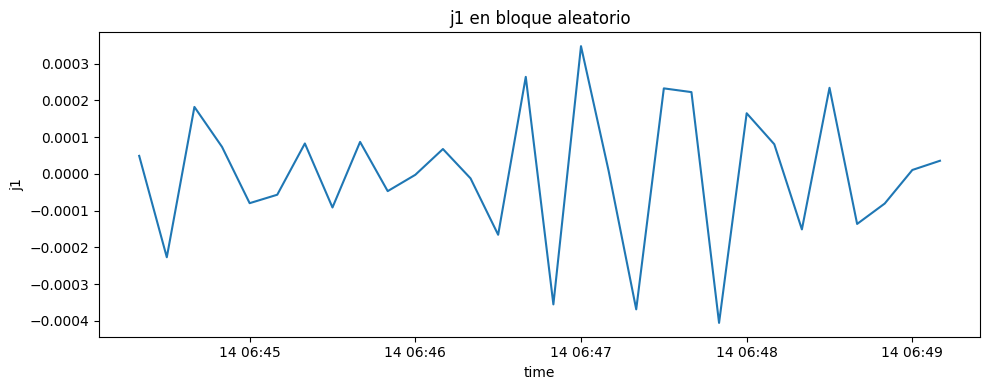

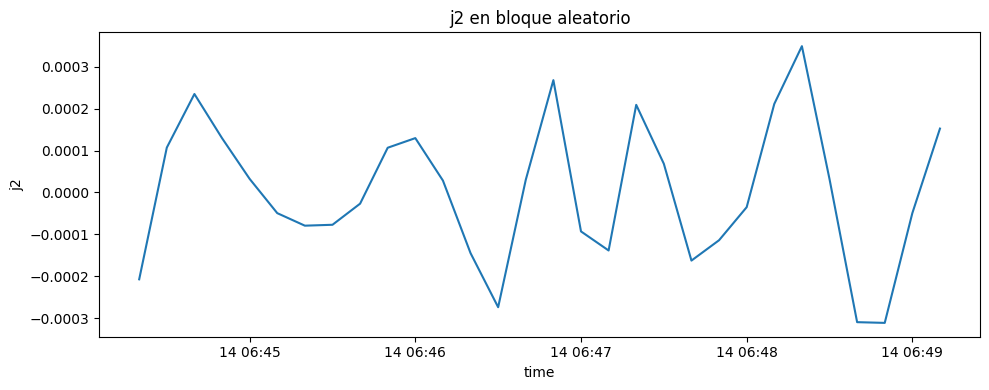

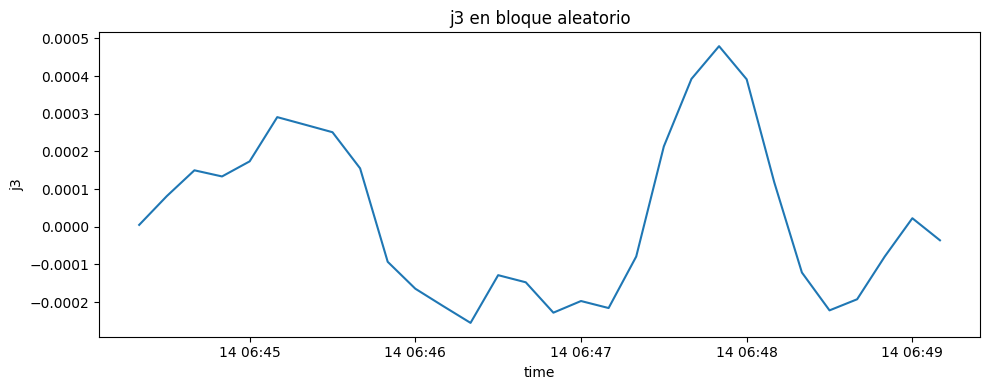

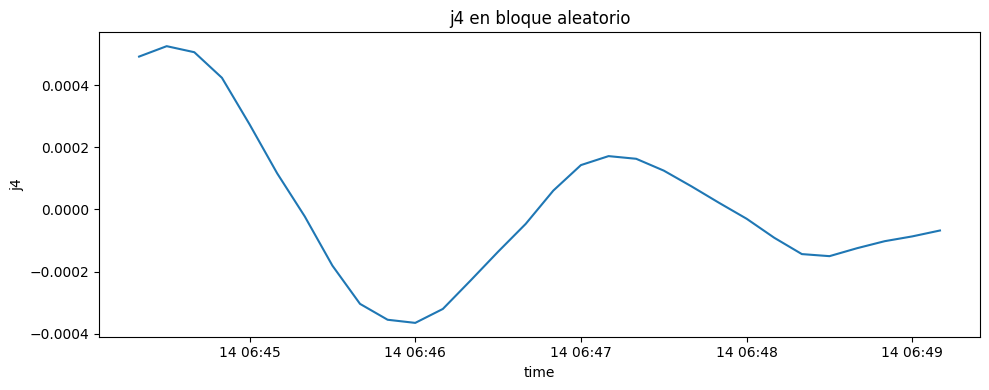

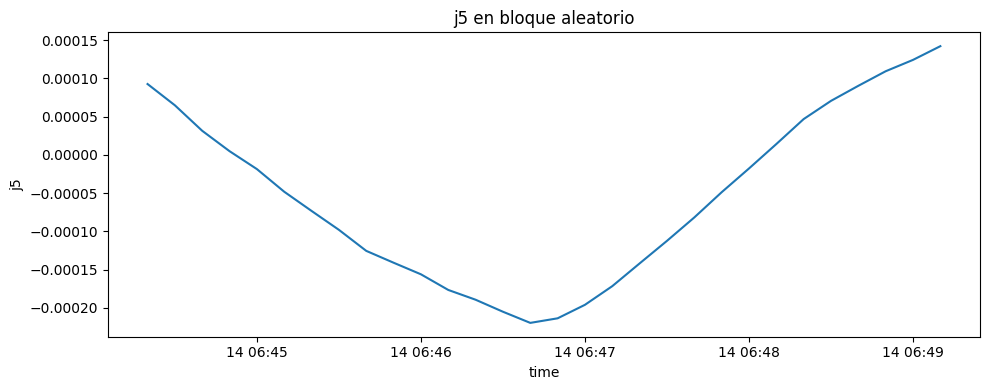

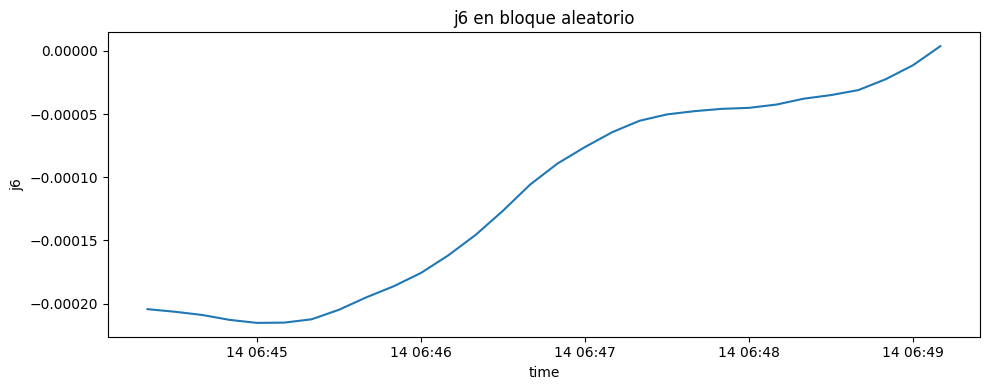

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 7)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

In [ ]:
for j in range(1, 7):
    c = df10[f"j{j}"]
    df10[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

Bloque elegido:
Inicio: 2024-06-14 08:06:46
Fin   : 2024-06-14 08:11:46


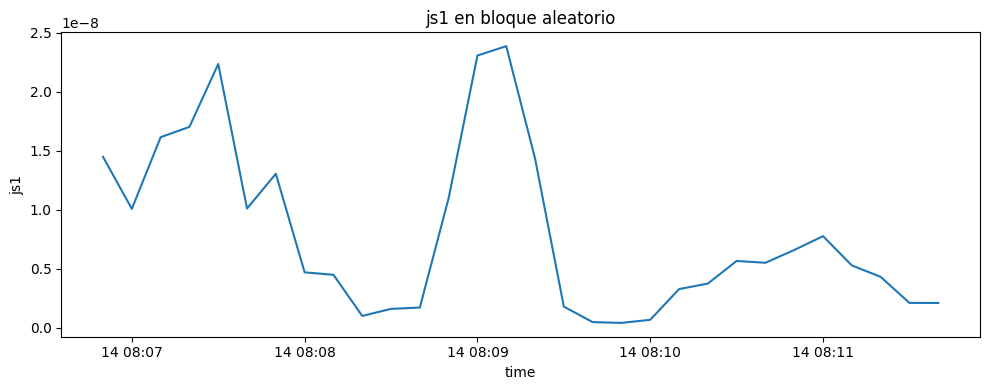

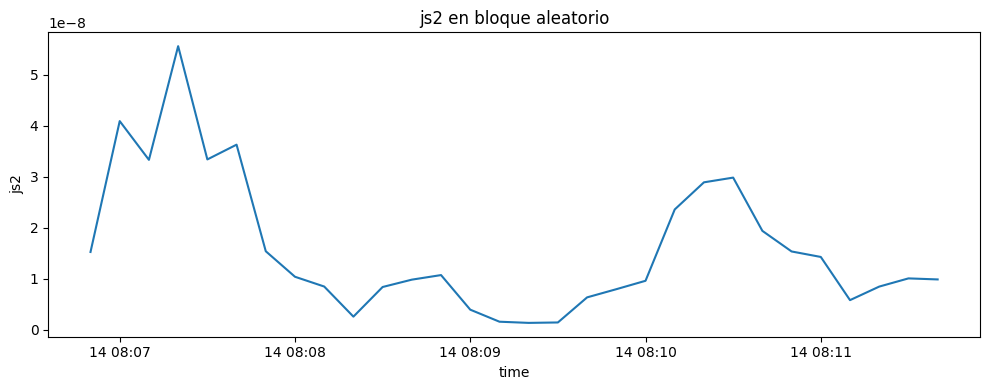

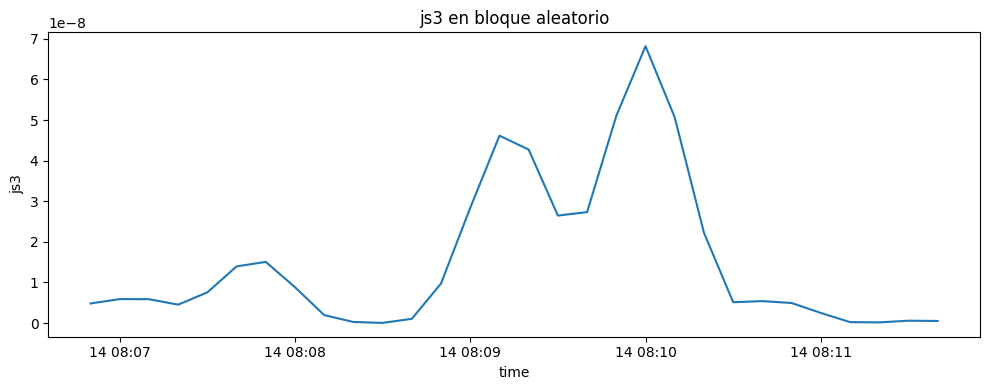

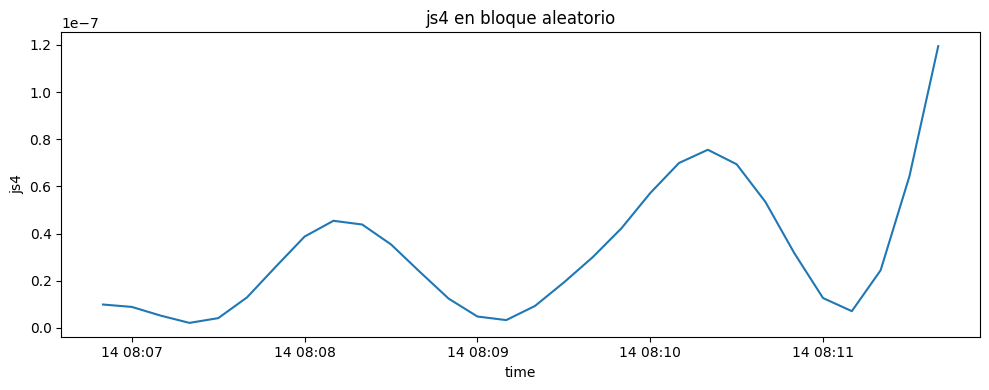

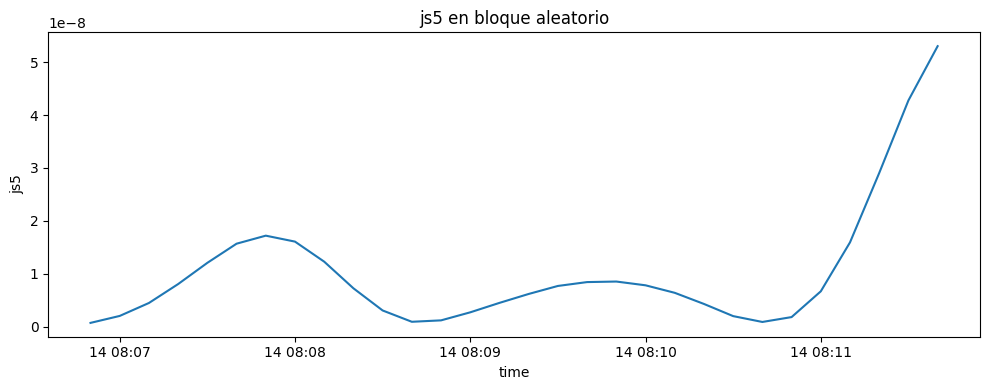

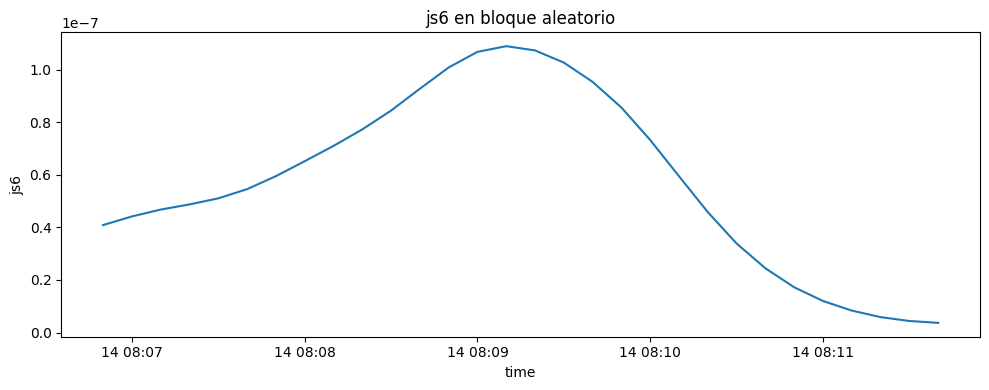

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 7)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()


*Eshort, Emedium and ELong all RAW*

In [ ]:
df10["des"] = df10["j1"] + df10["j2"]
df10["dem"] = df10["j3"] + df10["j4"]
df10["del"] = df10["j5"] + df10["j6"]

In [ ]:
s = df10["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df10["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df10["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 0
des Nulls: 0
dem Ceros: 0
dem Nulls: 0
del Ceros: 0
del Nulls: 0


In [ ]:
df10["de_total"] = df10["des"] + df10["dem"] + df10["del"]

In [ ]:
df10["dvol_wlt"] = np.sqrt(df10["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["dlog_vol_wlt"] = np.log(df10["dvol_wlt"])

***Eshort, Emedium and ELong all clean***

In [ ]:
df10["es"] = df10["js1"] + df10["js2"]
df10["em"] = df10["js3"] + df10["js4"]
df10["el"] = df10["js5"] + df10["js6"]

In [ ]:
s = df10["es"]
print("es Ceros:", (s == 0).sum())
print("es Nulls:", s.isna().sum())
s = df10["em"]
print("em Ceros:", (s == 0).sum())
print("em Nulls:", s.isna().sum())
s = df10["el"]
print("el Ceros:", (s == 0).sum())
print("el Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

es Ceros: 0
es Nulls: 0
em Ceros: 0
em Nulls: 0
el Ceros: 0
el Nulls: 0


In [ ]:
# dado que no hay ceros va sin epsilon

Bloque elegido:
Inicio: 2024-11-19 02:41:07
Fin   : 2024-11-19 02:46:07


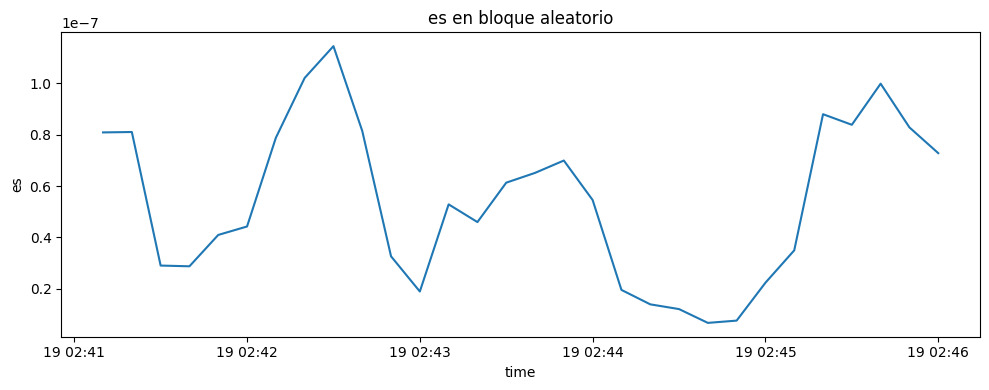

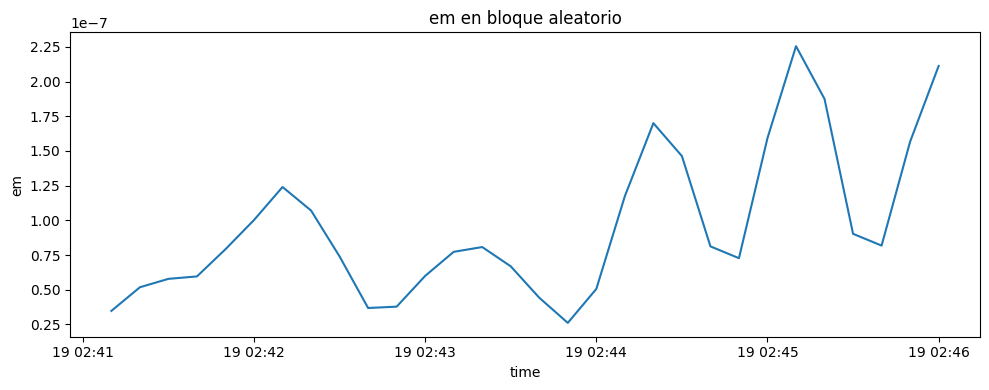

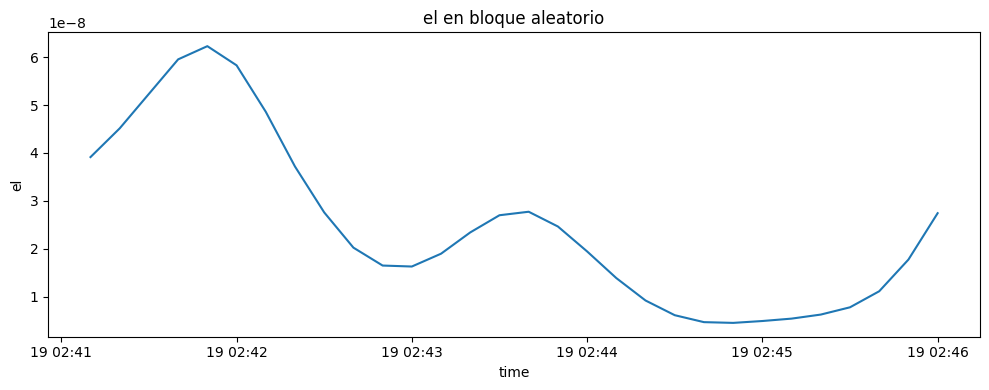

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_e = ["es", "em", "el"]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_e].dropna()

# 3) Graficar es, em y el
for c in cols_e:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[c])
    plt.title(f"{c} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(c)
    plt.tight_layout(); plt.show()


***Energia log-relativa***

In [ ]:
df10["e_total"] = df10["es"] + df10["em"] + df10["el"]
s = df10["e_total"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 0


In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_total"])
df10["erm"] = np.log((df10["em"]) / df10["e_total"])
df10["erl"] = np.log((df10["el"]) / df10["e_total"])

In [ ]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 32 columns):
 #   Column        Dtype         
---  ------        -----         
 0   time          datetime64[ns]
 1   day           int64         
 2   close         float64       
 3   close_ln      float64       
 4   r             float64       
 5   RV_r          float64       
 6   j1            float64       
 7   j2            float64       
 8   j3            float64       
 9   j4            float64       
 10  j5            float64       
 11  j6            float64       
 12  a6            float64       
 13  js1           float64       
 14  js2           float64       
 15  js3           float64       
 16  js4           float64       
 17  js5           float64       
 18  js6           float64       
 19  des           float64       
 20  dem           float64       
 21  del           float64       
 22  de_total      float64       
 23  dvol_wlt      float64       
 2

Bloque elegido:
Inicio: 2024-12-20 11:46:10
Fin   : 2024-12-20 12:16:10


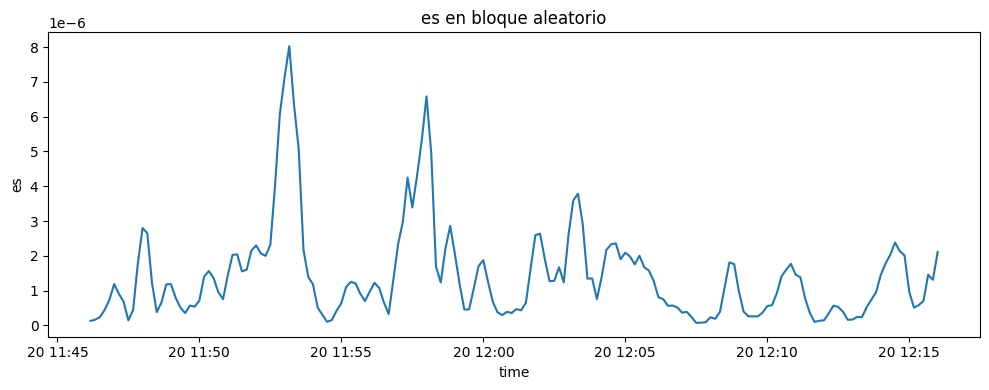

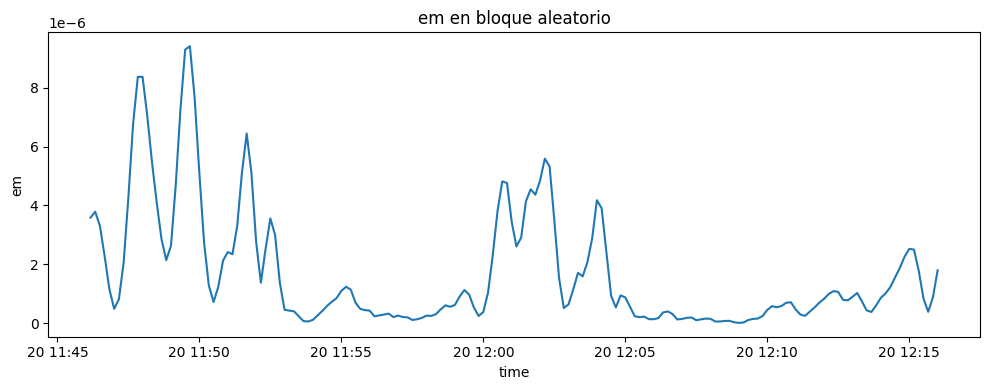

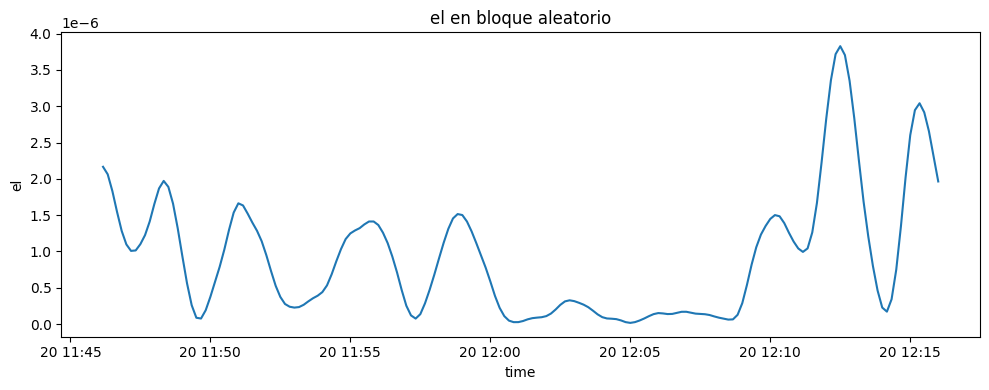

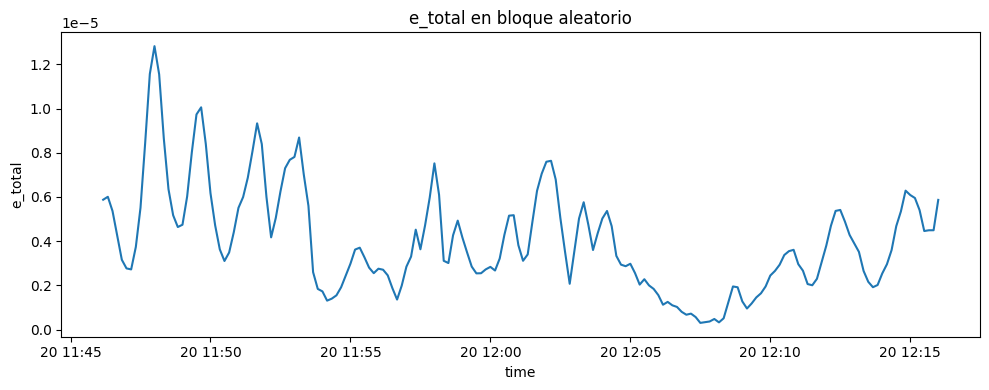

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=30)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_e = ["es", "em", "el", "e_total"]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_e].dropna()

# 3) Graficar es, em, el y e_total
for c in cols_e:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[c])
    plt.title(f"{c} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(c)
    plt.tight_layout(); plt.show()

In [ ]:
df10["vol_wlt"] = np.sqrt(df10["e_total"])

In [ ]:
s = df10["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 0


In [ ]:
df10["log_vol_wlt"] = np.log(df10["vol_wlt"])

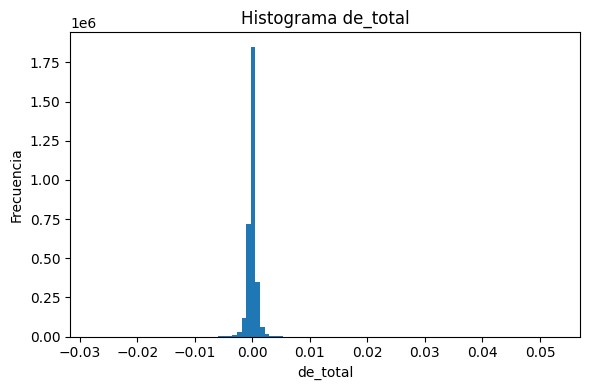

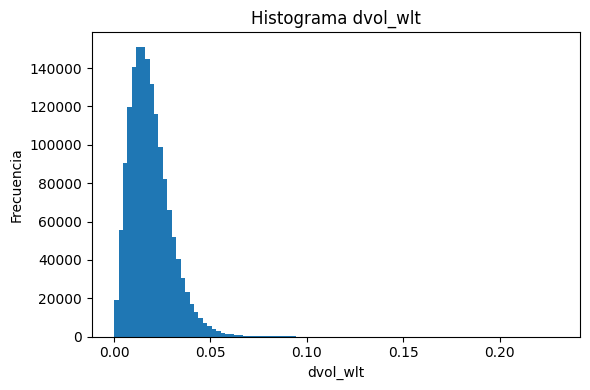

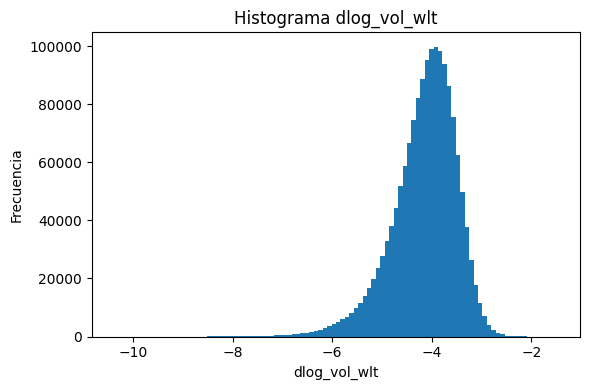

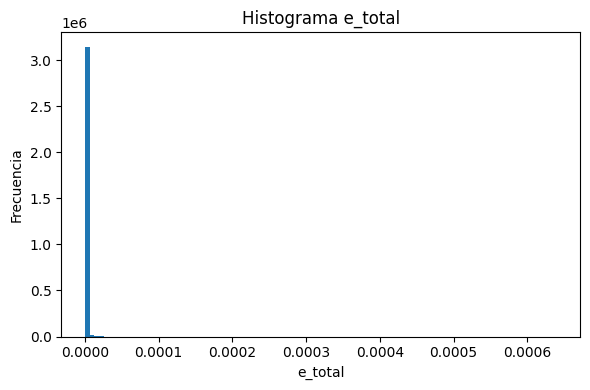

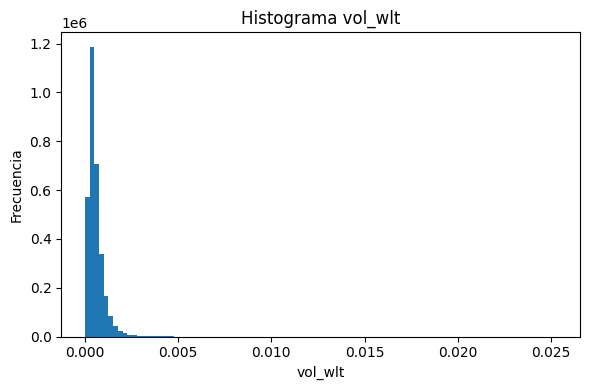

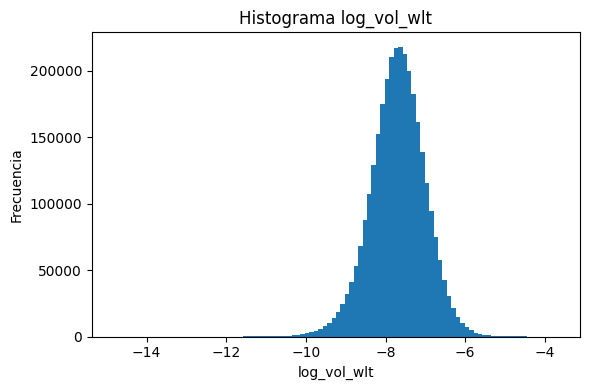

In [ ]:
import matplotlib.pyplot as plt
# Histograma de_total
plt.figure(figsize=(6,4))
plt.hist(df10["de_total"].dropna(), bins=100)
plt.title("Histograma de_total")
plt.xlabel("de_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma dvol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["dvol_wlt"].dropna(), bins=100)
plt.title("Histograma dvol_wlt")
plt.xlabel("dvol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma dlog_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["dlog_vol_wlt"].dropna(), bins=100)
plt.title("Histograma dlog_vol_wlt")
plt.xlabel("dlog_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df10["e_total"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

Individual checks

In [ ]:
import numpy as np
from scipy.stats import skew

s = df15["log_vol_wlt"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)



print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)

Media: -7.6951405930668475
Mediana: -7.6797583615507
Moda: -14.814499408957316
Desvío estándar: 0.6866558271615305
Skew: -0.24768430917128964


In [ ]:
# Moda por bindeo (más representativa)
counts, bins = np.histogram(s, bins=100)
moda_real = bins[np.argmax(counts)]
print("moda bins:", moda_real)

moda bins: -7.686795619731339


Deciles (0.1..0.9): [-8.548225151350989, -8.232745221413321, -8.019208997447066, -7.842356056001769, -7.6797583615507, -7.517218044153186, -7.342826576134334, -7.137836306079423, -6.850075070436032]
Permil 0.005: -9.747002813764164

ACF primeros 20 lags (lag: valor):
 0: 1.000000
 1: 0.985772
 2: 0.957224
 3: 0.926612
 4: 0.902901
 5: 0.884470
 6: 0.867567
 7: 0.853567
 8: 0.842209
 9: 0.834160
10: 0.826791
11: 0.818534
12: 0.809370
13: 0.800697
14: 0.793553
15: 0.788552
16: 0.785715
17: 0.784469
18: 0.783703
19: 0.782373
20: 0.780001


<Figure size 1000x400 with 0 Axes>

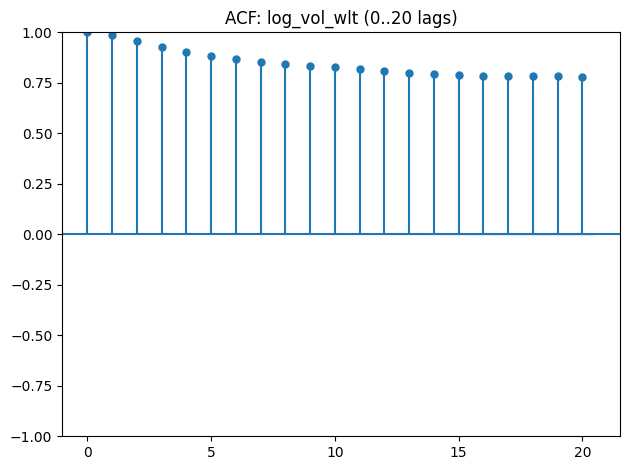


Top 5 días con más obs <= permil 0.005:
day
2024-06-23    1785
2024-06-22    1485
2024-06-09    1289
2024-10-20     923
2024-09-15     581
dtype: int64


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

s = df15["log_vol_wlt"].dropna()

# 1) Deciles + permil 0.005 (0.5%)
deciles = s.quantile(np.arange(0.1, 1.0, 0.1)).tolist()
p0005 = s.quantile(0.005)
print("Deciles (0.1..0.9):", deciles)
print("Permil 0.005:", p0005)

# 2) Autocorrelación: primeros 20 lags + gráfica
acf_vals = acf(s.values, nlags=20, fft=True)  # incluye lag 0
print("\nACF primeros 20 lags (lag: valor):")
for lag, val in enumerate(acf_vals[:21]):
    print(f"{lag:>2}: {val:.6f}")

plt.figure(figsize=(10,4))
plot_acf(s, lags=20, zero=True)
plt.title("ACF: log_vol_wlt (0..20 lags)")
plt.tight_layout()
plt.show()

# 3) Top 5 días con más observaciones <= permil 0.005
d = df15.loc[df15["log_vol_wlt"].le(p0005), ["time"]].dropna()
top5 = (d.assign(day=d["time"].dt.date)
         .groupby("day").size()
         .sort_values(ascending=False)
         .head(5))
print("\nTop 5 días con más obs <= permil 0.005:")
print(top5)

In [ ]:
s = df15["log_vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 0


Realized variance Test

In [ ]:
# Limpieza mínima
s = df15[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.16557027358617013
Spearman: 0.5153190529978882
Kendall : 0.3602789997613362


In [ ]:
# Limpieza mínima
s = df15[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.4228209095367485
Spearman: 0.5153190529978882
Kendall : 0.3602789997613362


In [ ]:
import statsmodels.api as sm

# Datos
y = df15["RV_r"]
X = df15["log_vol_wlt"]

# Limpieza mínima
mask = y.notna() & X.notna()
y = y[mask]
X = X[mask]

# OLS
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Estadísticos clave
print("Coeficientes:")
print(model.params, "\n")

print("R2:", model.rsquared)
print("R2 ajustado:", model.rsquared_adj)
print("F-stat:", model.fvalue)
print("p-value (F):", model.f_pvalue)
print("AIC:", model.aic)
print("BIC:", model.bic)

print("\nResumen completo:")
print(model.summary())

Bloques

In [ ]:
# Asegurar datetime
df15["time"] = pd.to_datetime(df15["time"])

# Setear índice temporal
df15_ = df15.set_index("time")

# Agregación a 15 minutos
df5m = df15_.resample("5T").agg({
    "RV_r": "sum",
    "e_total": "sum",
    "de_total": "sum",
    "log_vol_wlt": "mean",
    "vol_wlt": "mean"
}).reset_index()

df5m.head()

/tmp/ipython-input-3283487202.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df5m = df15_.resample("5T").agg({


,time,RV_r,e_total,de_total,log_vol_wlt,vol_wlt
0,2024-01-01 00:00:00,8.850302e-07,0.000005,-0.007871,-7.897892,0.000380
1,2024-01-01 00:05:00,8.128024e-07,0.000005,0.004274,-7.843989,0.000398
2,2024-01-01 00:10:00,7.139051e-07,0.000007,-0.006213,-7.664547,0.000473
3,2024-01-01 00:15:00,1.040920e-06,0.000007,0.005542,-7.686534,0.000468
4,2024-01-01 00:20:00,4.248116e-07,0.000006,-0.007190,-7.760870,0.000438


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.37199996020079695
Spearman: 0.9353337535127475
Kendall : 0.7874612700169711


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.8774666526779349
Spearman: 0.9189316864022443
Kendall : 0.7635214552776779


In [ ]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 28 columns):
 #   Column       Dtype         
---  ------       -----         
 0   time         datetime64[ns]
 1   day          int64         
 2   close        float64       
 3   close_ln     float64       
 4   r            float64       
 5   RV_r         float64       
 6   j1           float64       
 7   j2           float64       
 8   j3           float64       
 9   j4           float64       
 10  j5           float64       
 11  j6           float64       
 12  a6           float64       
 13  js1          float64       
 14  js2          float64       
 15  js3          float64       
 16  js4          float64       
 17  js5          float64       
 18  js6          float64       
 19  es           float64       
 20  em           float64       
 21  el           float64       
 22  e_total      float64       
 23  ers          float64       
 24  erm          float64   

### fr VPN productiva j=3 *

In [20]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.867754          0.132246        0.010111   
1    sym6  3      0.867436          0.132564        0.027775   
2    sym4  3      0.867674          0.132326        0.029308   
3     db6  3      0.867601          0.132399        0.030858   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003614        0.969032   430.287597  
1             0.004873        0.963715  1241.829204  
2             0.004746        0.961043  1270.757320  
3             0.005486        0.960648  1573.084635  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.03457333 0.07175279 0.13179832]
Shares por nivel (J...1):
[0.14519017 0.30132476 0.55348506]


In [ ]:
df15["RV_r"] = df15["r"]**2

Energia local suavizada

In [21]:
import numpy as np
import pandas as pd
import pywt
from scipy.signal import lfilter

def get_modwt_final_boss(df, col, w_name="db4", J=3):
    """
    MODWT Causal con Normalización de Percival & Walden,
    Notación Científica y Validación de Energía Ortogonal.
    """
    # 1. Preparación de datos
    x = df[col].fillna(0.0).values
    n = len(x)

    wavelet = pywt.Wavelet(w_name)
    h_base = wavelet.dec_hi / np.sqrt(2)
    g_base = wavelet.dec_lo / np.sqrt(2)
    L = len(h_base)

    current_a = x
    res_cols = []

    # 2. Descomposición Multinivel Causal
    for j in range(1, J + 1):
        step = 2**(j-1)
        # Dilatación del filtro (Algoritmo à trous)
        h_dil = np.zeros(L + (L - 1) * (step - 1))
        g_dil = np.zeros(L + (L - 1) * (step - 1))
        h_dil[::step] = h_base
        g_dil[::step] = g_base

        # Filtrado LFilter (Causalidad garantizada por Scipy)
        wj = lfilter(h_dil, [1.0], current_a)
        vj = lfilter(g_dil, [1.0], current_a)

        df[f"j{j}"] = wj
        res_cols.append(f"j{j}")
        current_a = vj

    df[f"a{J}"] = current_a
    res_cols.append(f"a{J}")

    # 3. Embargo y Auditoría Científica
    max_warmup = (L - 1) * (2**J - 1)

    # Limpiamos bordes para el test
    clean_df = df.iloc[max_warmup:].copy().dropna()

    if len(clean_df) > 100:
        # Usamos el mismo segmento para X y para los Coeficientes
        x_clean = x[max_warmup:max_warmup + len(clean_df)]

        var_x = np.var(x_clean, ddof=1)
        var_coeffs = clean_df[res_cols].var(ddof=1).sum()

        # Imprimir con precisión científica para evitar el "redondeo a cero"
        print("🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):")
        print(f"   Varianza Original (Var(x)): {var_x:.8e}")
        print(f"   Suma Varianzas (ΣVar):      {var_coeffs:.8e}")

        error_rel = np.abs(var_x - var_coeffs) / var_x if var_x > 0 else 0
        print(f"   Error Relativo:             {error_rel:.4%}")

        # Test de correlación (para demostrar que los niveles capturan info distinta)
        avg_corr = clean_df[res_cols].corr().abs().values[np.triu_indices(len(res_cols), k=1)].mean()
        print(f"   Correlación Media Inter-Nivel: {avg_corr:.4f}")

    # Aplicar NaNs de seguridad en el DataFrame original
    for col_res in res_cols:
        df.loc[df.index[:max_warmup], col_res] = np.nan

    return df

# Ejecución
df15 = get_modwt_final_boss(df15, "r", w_name="db4", J=3)

🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):
   Varianza Original (Var(x)): 1.30169814e-07
   Suma Varianzas (ΣVar):      1.30170004e-07
   Error Relativo:             0.0001%
   Correlación Media Inter-Nivel: 0.0007


In [22]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 10 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   RV_r      float64       
 6   j1        float64       
 7   j2        float64       
 8   j3        float64       
 9   a3        float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 160.8 MB


In [30]:
for j in range(1, 4):
    c = df15[f"j{j}"]
    df15[f"js{j}"] = (c*c).rolling(2, min_periods=1).mean()

In [31]:
df15["es"] = df15["js1"]
df15["em"] = df15["js2"]
df15["el"] = df15["js3"]

In [32]:
df15["e_d"] = df15["es"] + df15["em"] + df15["el"]
s = df15["e_d"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 49


In [33]:
df15["ers"] = np.log((df15["es"]) / df15["e_d"])
df15["erm"] = np.log((df15["em"]) / df15["e_d"])
df15["erl"] = np.log((df15["el"]) / df15["e_d"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [34]:
df15["vol_wlt"] = np.sqrt(df15["e_d"])

In [35]:
s = df15["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 49


In [36]:
df15["log_vol_wlt"] = np.log(df15["vol_wlt"])

In [38]:
df15["as3"] = (df15["a3"] * df15["a3"]).rolling(2, min_periods=1).mean()
df15["e_total"] = df15["es"] + df15["em"] + df15["el"] + df15["as3"]

In [39]:
df15["ers"] = np.log((df15["es"]) / df15["e_total"])
df15["erm"] = np.log((df15["em"]) / df15["e_total"])
df15["erl"] = np.log((df15["el"]) / df15["e_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [40]:
df15["tvol_wlt"] = np.sqrt(df15["e_total"])

In [41]:
s = df15["tvol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 49


In [42]:
df15["tlog_vol_wlt"] = np.log(df15["tvol_wlt"])

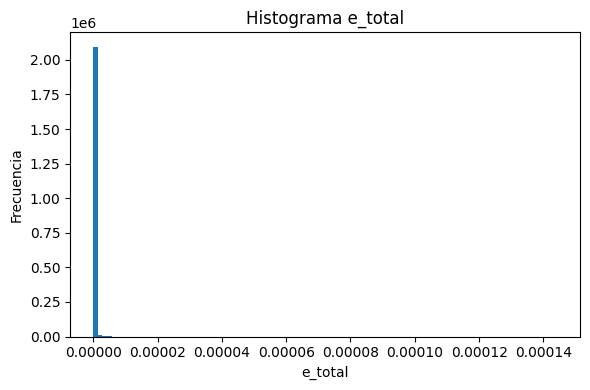

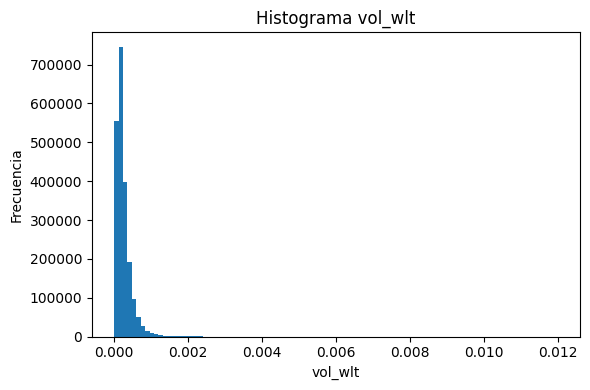

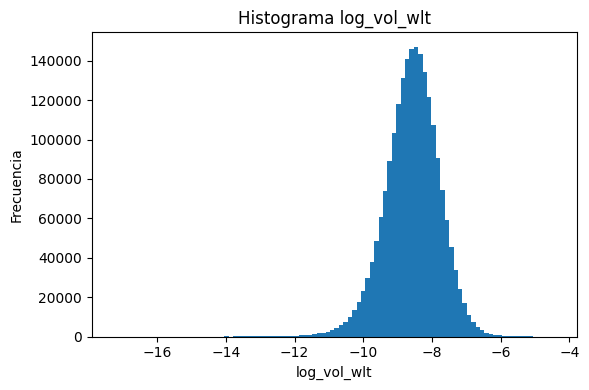

In [43]:
import matplotlib.pyplot as plt

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df15["e_d"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-01-11 19:18:51
Fin   : 2024-01-11 19:23:51


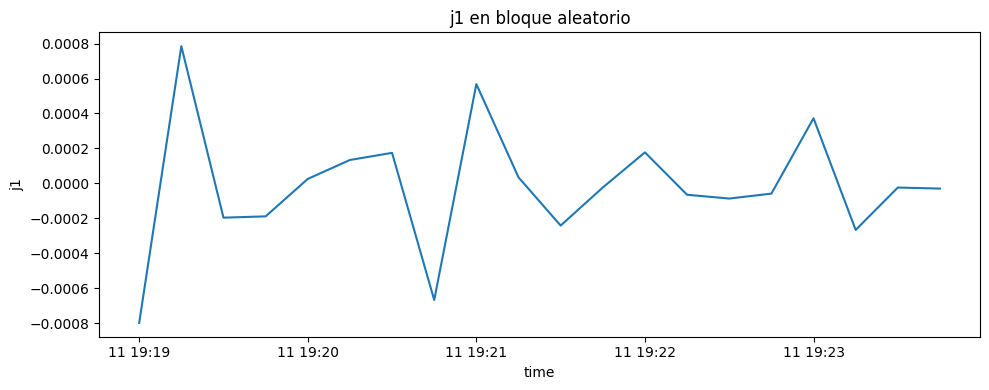

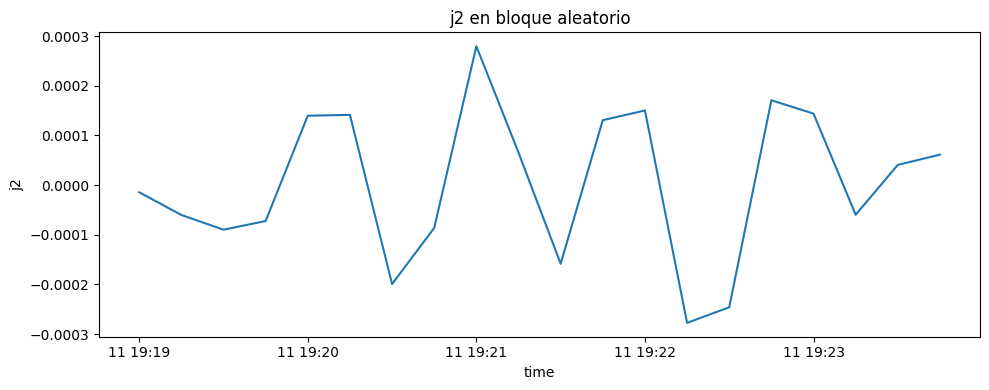

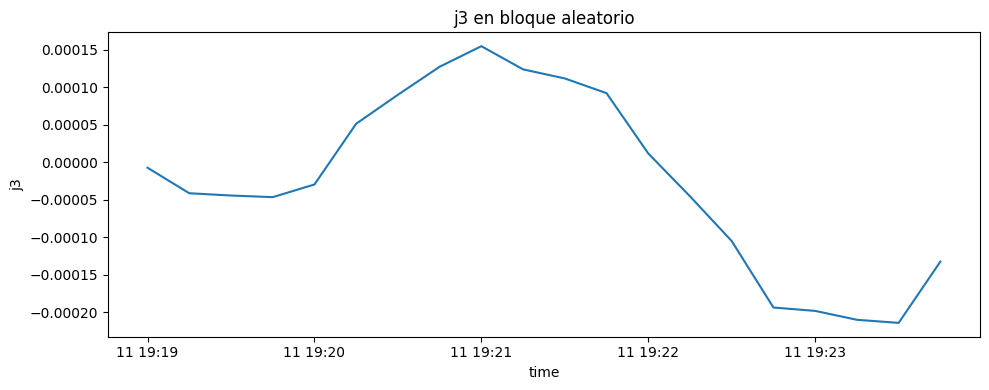

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 4)]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-05-19 10:56:30
Fin   : 2024-05-19 11:01:30


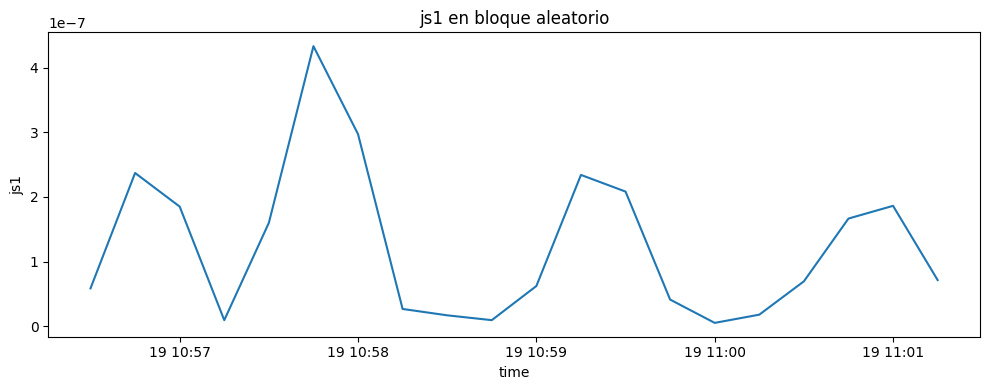

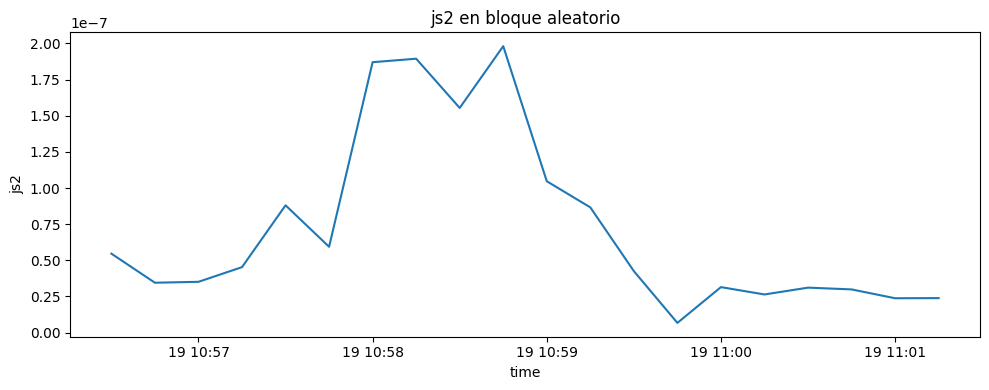

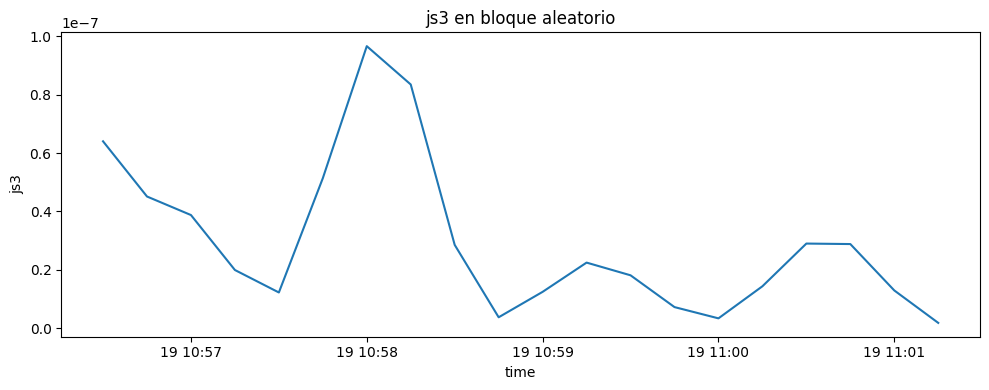

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 4)]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()

*Eshort, Emedium and ELong all RAW*

In [46]:
df15["des"] = df15["j1"]
df15["dem"] = df15["j2"]
df15["del"] = df15["j3"]

In [47]:
s = df15["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df15["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df15["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 204
des Nulls: 49
dem Ceros: 0
dem Nulls: 49
del Ceros: 0
del Nulls: 49


In [48]:
df15["de_total"] = df15["des"] + df15["dem"] + df15["del"]

In [49]:
df15["dvol_wlt"] = np.sqrt(df15["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [50]:
df15["dlog_vol_wlt"] = np.log(df15["dvol_wlt"])

***Signature Plot***

/tmp/ipython-input-4007401881.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()


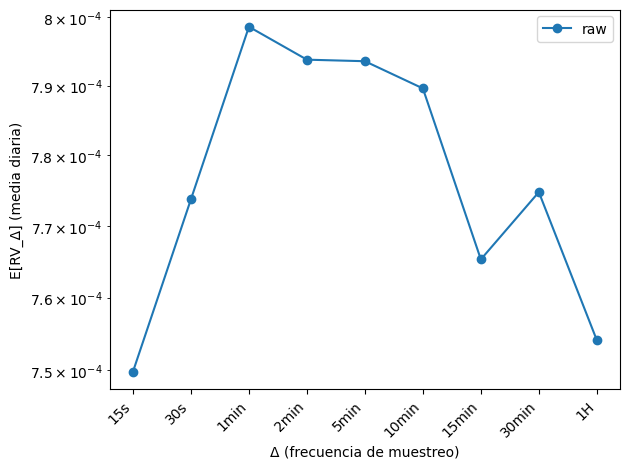

In [51]:
  #signature plot estandar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def signature_rv_15s(
    df,
    t="time",
    logp="close_ln",
    deltas=("15s","30s","1min","2min","5min","10min","15min","30min","1H")
):
    x = df[[t, logp]].dropna().copy()
    x = x.sort_values(t).set_index(t)

    out = []
    for d in deltas:
        lp = x[logp].resample(d).last().dropna()
        r  = lp.diff().dropna()

        rv_block = r.pow(2).groupby(r.index.floor("D")).sum()
        out.append((d, rv_block.mean(), rv_block.median(), rv_block.size))

    return pd.DataFrame(out, columns=["delta","RV_mean","RV_median","n_days"])


sig_raw = signature_rv_15s(df15)

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ] (media diaria)")
ax.set_xlabel("Δ (frecuencia de muestreo)")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipython-input-4007401881.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()
/tmp/ipython-input-4007401881.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()


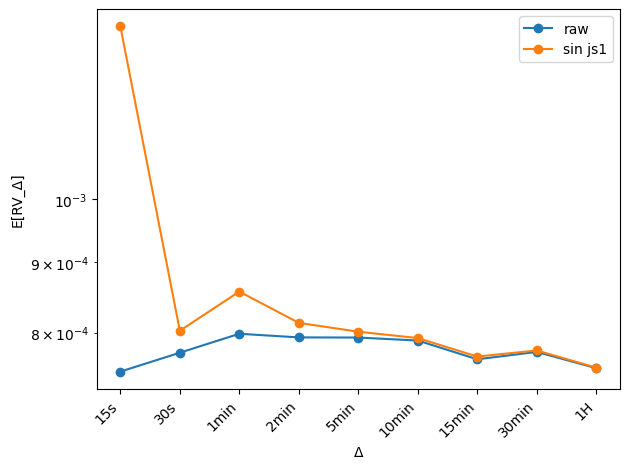

In [52]:
def add_clean_logprice_15s(
    df,
    t="time",
    logp="close_ln",
    r="r",
    j1="j1",
    out="close_ln_clean"
):
    x = df[[t, logp, r, j1]].dropna().copy()
    x = x.sort_values(t)

    r_clean = (x[r] - x[j1]).to_numpy()
    x[out] = x[logp].iloc[0] + np.cumsum(r_clean)

    return x


df15_clean = add_clean_logprice_15s(df15)

sig_raw   = signature_rv_15s(df15_clean, logp="close_ln")
sig_clean = signature_rv_15s(df15_clean, logp="close_ln_clean")

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.plot(sig_clean["RV_mean"].to_numpy(), marker="o", label="sin js1")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ]")
ax.set_xlabel("Δ")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def explosion_score(sig, k=5):
    y = np.log(sig["RV_mean"].to_numpy())
    x = np.log(np.arange(1, len(y) + 1))
    return (y[k] - y[0]) / (x[k] - x[0])

score_raw   = explosion_score(sig_raw)
score_clean = explosion_score(sig_clean)

score_raw, score_clean

(np.float64(0.02858545655243811), np.float64(-0.11057700345805258))

####SHAP

**1 min**

In [83]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1 min = 4 muestras de 15s)
    horizon_samples = int(horizon_secs / 15)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_min = 4 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 4 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [84]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=4, warmup_samples=49)

for train_idx, test_idx in splitter.split(df15):
    # Aquí entrenas tu modelo con df15.iloc[train_idx]
    # Y validas con df15.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [85]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df15, horizon_samples=4, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:351350] | Gap: 5 | Test[351355:702705]
   Fold 2: Train[49:702701] | Gap: 5 | Test[702706:1054056]
   Fold 3: Train[49:1054052] | Gap: 5 | Test[1054057:1405407]
   Fold 4: Train[49:1405403] | Gap: 5 | Test[1405408:1756758]
   Fold 5: Train[49:1756754] | Gap: 5 | Test[1756759:2108109]


In [86]:
horizon = 4
df15["log_vol_future"] = df15["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.507133  0.261207  0.511084  0.399204  0.519126  351342
1     2  0.564801  0.327275  0.572080  0.433251  0.582252  351342
2     3  0.520945  0.255262  0.505235  0.393238  0.523573  351342
3     4  0.550613  0.272808  0.522310  0.403578  0.554672  351342
4     5  0.497427  0.243112  0.493064  0.386185  0.501166  351342

PROMEDIO:
R2      0.528184
MSE     0.271933
RMSE    0.520755
MAE     0.403091
EVS     0.536158
dtype: float64


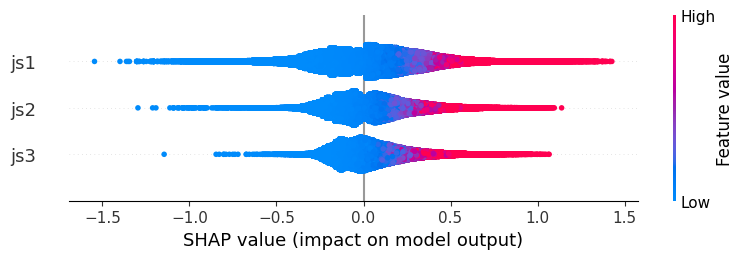

In [87]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 4, 49

# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**1 min navie**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.497159  0.266492  0.516229  0.404886  0.512795  351343
1     2  0.528841  0.354317  0.595246  0.442797  0.549030  351343
2     3  0.506460  0.262987  0.512822  0.400161  0.510366  351343
3     4  0.532579  0.283750  0.532682  0.411411  0.536901  351343
4     5  0.487015  0.248156  0.498152  0.390375  0.492365  351343

PROMEDIO:
R2      0.510411
MSE     0.283141
RMSE    0.531026
MAE     0.409926
EVS     0.520291
dtype: float64


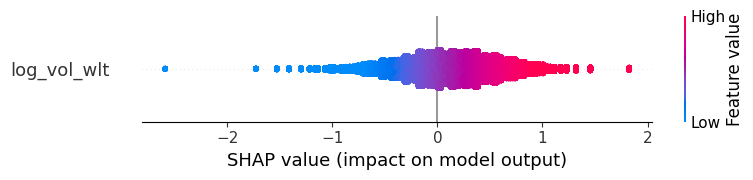

In [69]:

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE

 #NAVIE                            #NAVIE                              #NAVIE

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#

import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd


class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["log_vol_wlt"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 4, 49

# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**1 min + Shift(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.507133  0.261207  0.511084  0.399204  0.519126  351342
1     2  0.564801  0.327275  0.572080  0.433251  0.582252  351342
2     3  0.520945  0.255262  0.505235  0.393238  0.523573  351342
3     4  0.550613  0.272808  0.522310  0.403578  0.554672  351342
4     5  0.497427  0.243112  0.493064  0.386185  0.501166  351342

PROMEDIO:
R2      0.528184
MSE     0.271933
RMSE    0.520755
MAE     0.403091
EVS     0.536158
dtype: float64


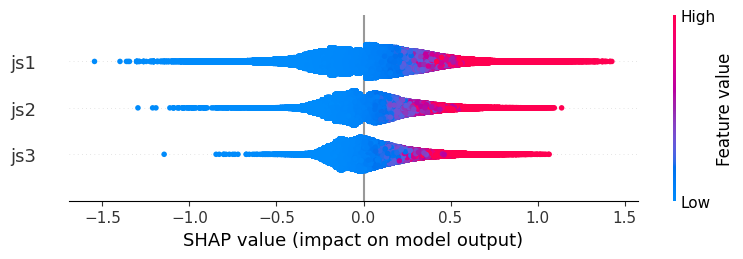

In [70]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 4, 49  # 6*10s = 1 min

# shift causal de features
df15[features] = df15[features].shift(1)


# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)




**1 min navie +shifted(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.500539  0.264701  0.514491  0.402724  0.515816  351342
1     2  0.533969  0.350464  0.592000  0.439539  0.553907  351342
2     3  0.512485  0.259767  0.509674  0.396985  0.516286  351342
3     4  0.537806  0.280585  0.529703  0.408299  0.541976  351342
4     5  0.491380  0.246037  0.496021  0.388653  0.496629  351342

PROMEDIO:
R2      0.515236
MSE     0.280311
RMSE    0.528378
MAE     0.407240
EVS     0.524923
dtype: float64


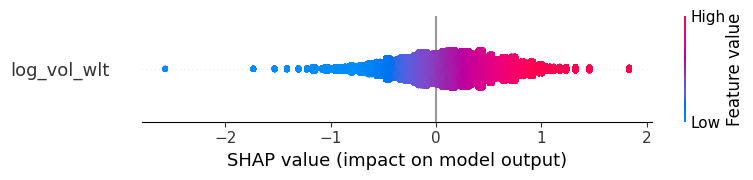

In [72]:
#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE

 #NAVIE                            #NAVIE                              #NAVIE

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#

import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd


class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["log_vol_wlt"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 4, 49
# shift causal de features
df15[features] = df15[features].shift(1)


# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)



**1 min navie +shifted(-4)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.800910  0.105513  0.324828  0.251269  0.802774  351343
1     2  0.803006  0.148144  0.384895  0.270822  0.806008  351343
2     3  0.803524  0.104689  0.323557  0.249715  0.804035  351343
3     4  0.813054  0.113490  0.336883  0.255943  0.813598  351343
4     5  0.791533  0.100843  0.317557  0.245825  0.792278  351343

PROMEDIO:
R2      0.802406
MSE     0.114536
RMSE    0.337544
MAE     0.254715
EVS     0.803739
dtype: float64


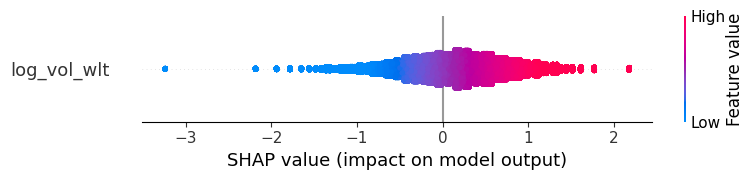

In [89]:
#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE

 #NAVIE                            #NAVIE                              #NAVIE

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#

import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd


class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["log_vol_wlt"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 4, 49
# shift causal de features
df15[features] = df15[features].shift(-4)


# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

**HF**

In [73]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1/6 min = 1 muestras de 15s)
    horizon_samples = int(horizon_secs / 15)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_min = 1 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 1 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [74]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=1, warmup_samples=49)

for train_idx, test_idx in splitter.split(df15):
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [75]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 1/6 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df15, horizon_samples=1, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:351350] | Gap: 2 | Test[351352:702702]
   Fold 2: Train[49:702701] | Gap: 2 | Test[702703:1054053]
   Fold 3: Train[49:1054052] | Gap: 2 | Test[1054054:1405404]
   Fold 4: Train[49:1405403] | Gap: 2 | Test[1405405:1756755]
   Fold 5: Train[49:1756754] | Gap: 2 | Test[1756756:2108106]


In [76]:
horizon = 1
df15["log_vol_future"] = df15["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.633201  0.194396  0.440903  0.344527  0.637622  351343
1     2  0.693320  0.230631  0.480241  0.367258  0.700532  351343
2     3  0.637973  0.192898  0.439202  0.342440  0.638478  351343
3     4  0.668202  0.201428  0.448807  0.348553  0.670384  351343
4     5  0.617746  0.184910  0.430011  0.336360  0.618445  351343

PROMEDIO:
R2      0.650088
MSE     0.200853
RMSE    0.447833
MAE     0.347828
EVS     0.653092
dtype: float64


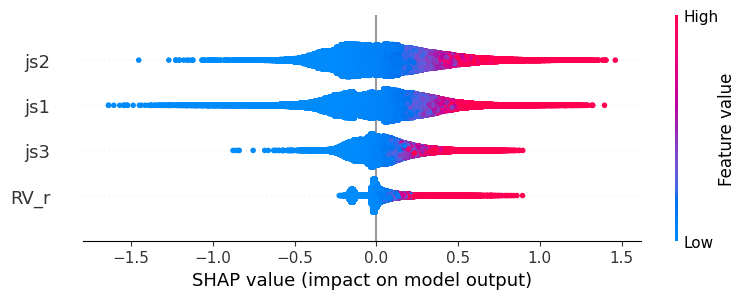

In [78]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3","RV_r"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49

# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.610953  0.206186  0.454078  0.353943  0.617281  351343
1     2  0.672534  0.246263  0.496249  0.377868  0.681697  351343
2     3  0.617825  0.203634  0.451258  0.351087  0.618988  351343
3     4  0.648689  0.213274  0.461816  0.357670  0.651145  351343
4     5  0.596590  0.195143  0.441750  0.344961  0.598327  351343

PROMEDIO:
R2      0.629318
MSE     0.212900
RMSE    0.461030
MAE     0.357106
EVS     0.633488
dtype: float64


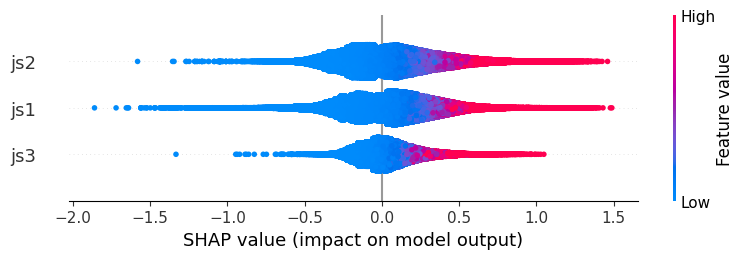

In [79]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49

# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

**15 segs + Shift(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.539108  0.244262  0.494229  0.386428  0.548786  351343
1     2  0.598924  0.301619  0.549198  0.417482  0.613281  351343
2     3  0.546532  0.241624  0.491552  0.383367  0.548702  351343
3     4  0.579610  0.255208  0.505181  0.391249  0.583385  351343
4     5  0.526122  0.229232  0.478782  0.374705  0.529347  351343

PROMEDIO:
R2      0.558059
MSE     0.254389
RMSE    0.503788
MAE     0.390646
EVS     0.564700
dtype: float64


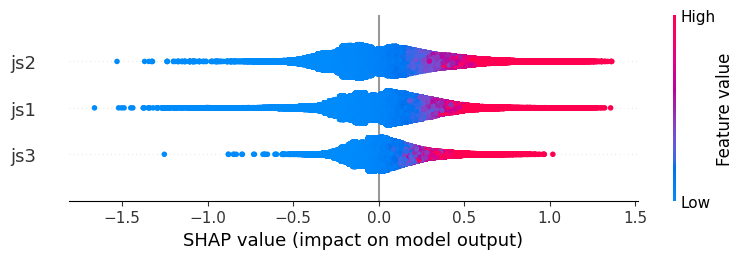

In [80]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49  # 6*10s = 1 min

# shift causal de features
df15[features] = df15[features].shift(1)


# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


In [ ]:
#descubrimos una filtracion muy ligera pero exitente, por tanto trabajaremos de ahora en mas con shift(1)

**2 min**

In [90]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras
    horizon_samples = int(horizon_secs / 15)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1)
horizon_min = 8 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 8 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [91]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=8, warmup_samples=49)

for train_idx, test_idx in splitter.split(df15):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [92]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df15, horizon_samples=8, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:351350] | Gap: 9 | Test[351359:702709]
   Fold 2: Train[49:702701] | Gap: 9 | Test[702710:1054060]
   Fold 3: Train[49:1054052] | Gap: 9 | Test[1054061:1405411]
   Fold 4: Train[49:1405403] | Gap: 9 | Test[1405412:1756762]
   Fold 5: Train[49:1756754] | Gap: 9 | Test[1756763:2108113]


In [93]:
horizon = 8
df15["log_vol_future"] = df15["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.393707  0.321319  0.566850  0.445850  0.414701  351341
1     2  0.417629  0.437941  0.661771  0.494580  0.448373  351341
2     3  0.410823  0.313997  0.560354  0.438226  0.415616  351341
3     4  0.428321  0.347012  0.589077  0.454453  0.435378  351341
4     5  0.393052  0.293618  0.541865  0.426707  0.399713  351341

PROMEDIO:
R2      0.408707
MSE     0.342777
RMSE    0.583983
MAE     0.451963
EVS     0.422756
dtype: float64


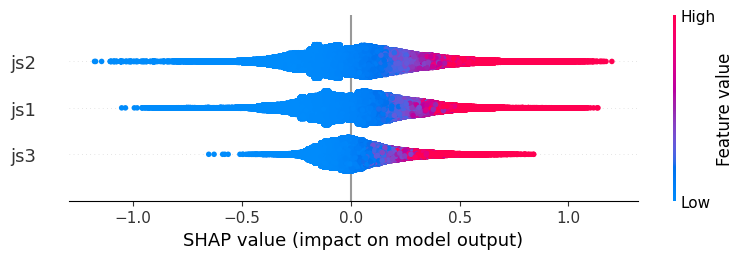

In [94]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 12, 49

# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]
# shift causal de features
df15[features] = df15[features].shift(1)

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**5 min**

In [95]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras
    horizon_samples = int(horizon_secs / 15)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1)
horizon_min = 20 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 20 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [96]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=20, warmup_samples=49)

for train_idx, test_idx in splitter.split(df15):
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [97]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 5 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df15, horizon_samples=20, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:351350] | Gap: 21 | Test[351371:702721]
   Fold 2: Train[49:702701] | Gap: 21 | Test[702722:1054072]
   Fold 3: Train[49:1054052] | Gap: 21 | Test[1054073:1405423]
   Fold 4: Train[49:1405403] | Gap: 21 | Test[1405424:1756774]
   Fold 5: Train[49:1756754] | Gap: 21 | Test[1756775:2108125]


In [98]:
horizon = 20
df15["log_vol_future"] = df15["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.370162  0.333802  0.577756  0.454954  0.392221  351338
1     2  0.349032  0.489498  0.699641  0.515508  0.389454  351338
2     3  0.381079  0.329893  0.574364  0.448931  0.386365  351338
3     4  0.385717  0.372848  0.610612  0.468435  0.394821  351338
4     5  0.373053  0.303293  0.550721  0.433635  0.378398  351338

PROMEDIO:
R2      0.371809
MSE     0.365867
RMSE    0.602619
MAE     0.464293
EVS     0.388252
dtype: float64


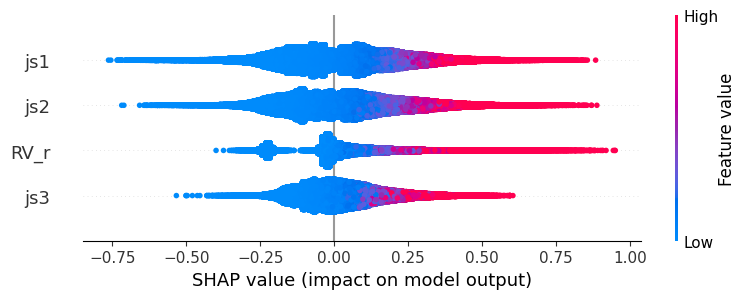

In [99]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3","RV_r"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 20, 49

# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]
# shift causal de features
df15[features] = df15[features].shift(1)

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


In [ ]:
# TOP HORIZONTES (todos con shift(1))
# 1 MINUTO *
# 2 MINUTOS

#### SHAP REGIMENES

**1 min**

In [100]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1 min = 4 muestras de 15s)
    horizon_samples = int(horizon_secs / 15)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_min = 4 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 4 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [101]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=4, warmup_samples=49)

for train_idx, test_idx in splitter.split(df15):
    # Aquí entrenas tu modelo con df15.iloc[train_idx]
    # Y validas con df15.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [102]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df15, horizon_samples=4, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:351350] | Gap: 5 | Test[351355:702705]
   Fold 2: Train[49:702701] | Gap: 5 | Test[702706:1054056]
   Fold 3: Train[49:1054052] | Gap: 5 | Test[1054057:1405407]
   Fold 4: Train[49:1405403] | Gap: 5 | Test[1405408:1756758]
   Fold 5: Train[49:1756754] | Gap: 5 | Test[1756759:2108109]


In [103]:
horizon = 4
df15["log_vol_future"] = df15["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.399513  0.318243  0.564130  0.443477  0.419915  351341
1     2  0.425456  0.432061  0.657313  0.491689  0.455439  351341
2     3  0.417223  0.310546  0.557267  0.435373  0.421946  351341
3     4  0.434296  0.343411  0.586013  0.451885  0.441267  351341
4     5  0.399402  0.290536  0.539014  0.424180  0.405983  351341

PROMEDIO:
R2      0.415178
MSE     0.338959
RMSE    0.580747
MAE     0.449321
EVS     0.428910
dtype: float64


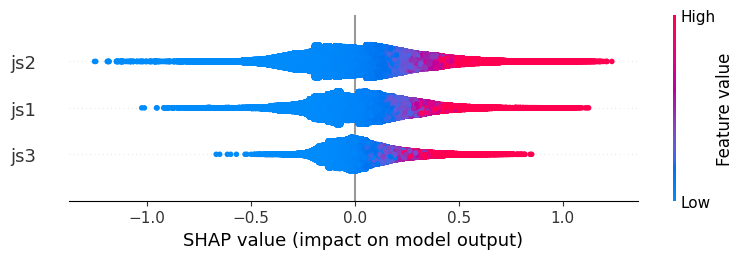

In [104]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 4, 49  # 6*10s = 1 min

# shift causal de features
df15[features] = df15[features].shift(1)


# --- data ---
df = df15[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

/tmp/ipython-input-825591050.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  regime_metrics = analysis.groupby('Regime', observed=True).apply(lambda x: pd.Series({
/tmp/ipython-input-825591050.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Regime', y='Error', data=analysis, palette='viridis')


📊 MÉTRICAS POR RÉGIMEN DE VOLATILIDAD:
                  R2       MAE      Bias    Count
Regime                                           
Baja        0.053290  0.468440  0.209339  70269.0
Media-Baja  0.019719  0.396628  0.035195  70268.0
Media      -0.037392  0.389733 -0.063098  70268.0
Media-Alta -0.146951  0.402580 -0.158006  70268.0
Alta       -0.328179  0.463519 -0.305556  70268.0


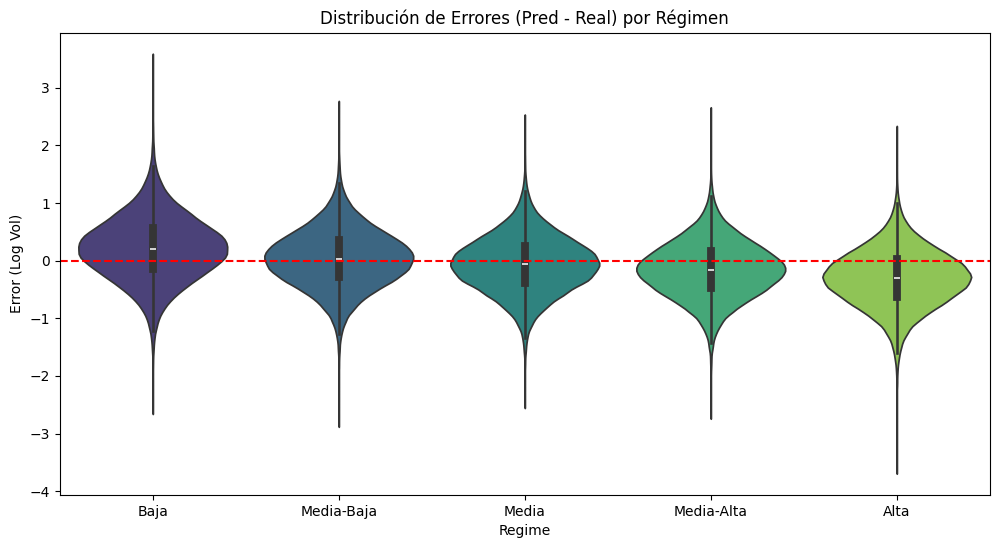

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperamos la volatilidad actual para el último fold de test
# Asumimos que 'log_vol_now' está alineada con 'last_Xte'
vol_now_test = df15.loc[last_Xte.index, "log_vol_wlt"]

# 2. Creamos los 5 regímenes basados en quintiles
regime_labels = ['Baja', 'Media-Baja', 'Media', 'Media-Alta', 'Alta']
regimes = pd.qcut(vol_now_test, 5, labels=regime_labels)

# 3. Construimos el DataFrame de análisis de residuos
analysis = pd.DataFrame({
    'Real': last_yte,
    'Pred': last_model.predict(last_Xte),
    'Regime': regimes
})
analysis['Error'] = analysis['Pred'] - analysis['Real']
analysis['AbsError'] = analysis['Error'].abs()

# 4. Cálculo de métricas por régimen
regime_metrics = analysis.groupby('Regime', observed=True).apply(lambda x: pd.Series({
    'R2': r2_score(x['Real'], x['Pred']),
    'MAE': x['AbsError'].mean(),
    'Bias': x['Error'].mean(),
    'Count': len(x)
}))

print("📊 MÉTRICAS POR RÉGIMEN DE VOLATILIDAD:")
print(regime_metrics)

# 5. Visualización de la "Firma del Error"
plt.figure(figsize=(12, 6))
sns.violinplot(x='Regime', y='Error', data=analysis, palette='viridis')
plt.axhline(0, color='red', linestyle='--')
plt.title('Distribución de Errores (Pred - Real) por Régimen')
plt.ylabel('Error (Log Vol)')
plt.show()

In [ ]:
# el modelo es mas preciso en los extremos, el R2 no es importante por la microvarianza inherente al experimento
# Posibles complementos
# 1. modelo truncado
# 2. Wavelet mas larga Js


# complemento indispensable:
# rolling explosition score from signature plot, a 1 hora, 2 horas, o algo asi

####Blocks minutes

15 minutes

In [106]:
import numpy as np
import pandas as pd

df15["time"] = pd.to_datetime(df15["time"])
df_ = df15.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("15T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-3233109994.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("15T").mean()
/tmp/ipython-input-3233109994.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [107]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [108]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.9192122976236975
Spearman: 0.9631925523652018
Kendall : 0.8399588965071751


In [109]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.9631925523652018
Kendall : 0.8399588965071751


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


5 minutes

In [110]:
import numpy as np
import pandas as pd

df15["time"] = pd.to_datetime(df15["time"])
df_ = df15.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("5T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-304541807.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("5T").mean()
/tmp/ipython-input-304541807.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [111]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [112]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.9177454697461224
Spearman: 0.958397756830083
Kendall : 0.829354444755176


In [113]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


Pearson : nan
Spearman: 0.958397756830083
Kendall : 0.829354444755176


1 minute

In [114]:
import numpy as np
import pandas as pd

df15["time"] = pd.to_datetime(df15["time"])
df_ = df15.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("1T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-2248139847.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("1T").mean()
/tmp/ipython-input-2248139847.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [115]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [116]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.9177454697461224
Spearman: 0.958397756830083
Kendall : 0.829354444755176


In [117]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.958397756830083
Kendall : 0.829354444755176


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


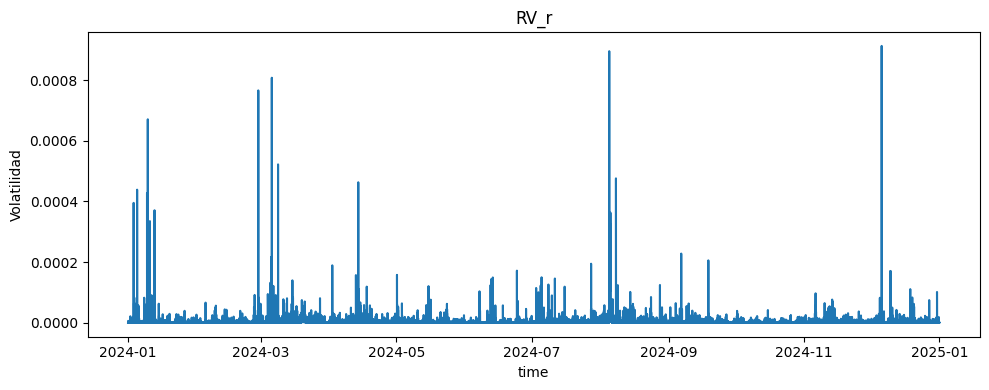

In [118]:
s = df15m["RV_r"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("RV_r")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

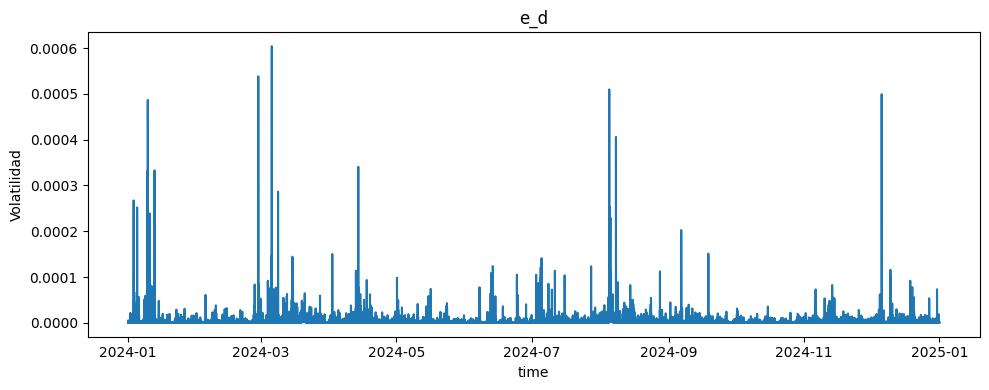

In [119]:
s = df15m["e_d"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("e_d")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

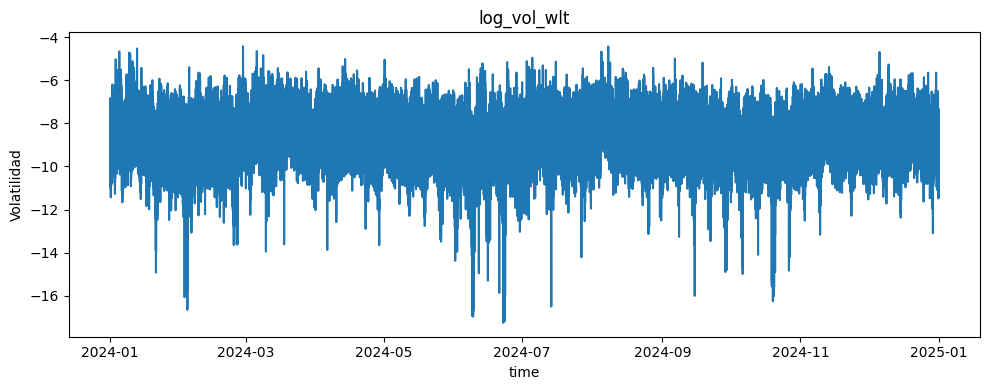

In [120]:
s = df15["log_vol_wlt"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15.loc[s.index, "time"], s.values)
plt.title("log_vol_wlt")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

***Test iniciales***

In [121]:
import pandas as pd

x = df15m["vol_wlt"]
r = df15m["r"]

corr_t   = x.corr(r)
corr_tp1 = x.corr(r.shift(-1))

corr_t, corr_tp1

(np.float64(-0.010113317829416803), np.float64(-0.020828908926170557))

In [ ]:
#no hay leakage

In [122]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lags = [5, 10, 20]

lb_js = {
    f"js{i}": acorr_ljungbox(df15m[f"js{i}"].dropna(), lags=lags, return_df=True)
    for i in [1, 2, 3]
}

lb_js

{'js1':          lb_stat  lb_pvalue
 5   53510.540023        0.0
 10  71876.595961        0.0
 20  90108.840569        0.0,
 'js2':          lb_stat  lb_pvalue
 5   52111.616863        0.0
 10  65372.026496        0.0
 20  78479.090940        0.0,
 'js3':          lb_stat  lb_pvalue
 5   31106.616813        0.0
 10  39078.609151        0.0
 20  45928.137027        0.0}

In [ ]:
#La volatilidad wavelet no es un artefacto de microestructura.
# POR LO TANTO; la vairable no es una varianza fisica sino es un estado latente de intensidad

In [123]:
import numpy as np

targets = df15m["RV_r"]

corr_levels = {
    "js1": df15m["js1"].corr(targets),
    "js2": df15m["js2"].corr(targets),
    "js3": df15m["js3"].corr(targets),
}

corr_levels

{'js1': np.float64(0.8111669443654926),
 'js2': np.float64(0.5782814663121332),
 'js3': np.float64(0.3338276297786792)}

In [ ]:
#La señal es multiescala, no un truco de j1, por lo cual no es imprecindible

In [124]:
vol_23 = np.sqrt(df15m["js2"]**2 + df15m["js3"]**2)
vol_23 = np.log(vol_23.replace(0, np.nan))

vol_23.corr(targets)

np.float64(0.32805626952405637)

In [ ]:
#Spearman alto es legítimo, no inflado artificialmente.

In [ ]:
# CONCLUSION
# Si la querés target en un GAT, hacelo ordinal (bins) y entrená para:

# alta Kendall/Spearman out-of-sample,

# estabilidad rolling,

# y consistencia de edges en ventanas.

# La versión “continua con MSE” es posible, pero es pelearte con la geometría equivocada: como medir temperatura con una regla.

# Si me decís cuántos activos y qué frecuencia (5m / 15m), te propongo la definición mínima de:

# nodos/features,

# edges (qué medida usar),

# y el head ordinal (K y thresholds) para que quede coherente con tu proxy.

# CVS

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# import pandas as pd

Mounted at /content/drive


SAVE

In [ ]:
# # Montar Google Drive
# drive.mount('/content/drive')

# # Ruta donde querés guardar el archivo (podés cambiar el nombre o carpeta)
# ruta_guardado = '/content/drive/MyDrive/VFJmf1.parquet'

# # Guardar en formato Parquet, conservando la estructura y tipos
# mf1.to_parquet(ruta_guardado, index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


APERTURA

In [ ]:
# mf1 = pd.read_parquet('/content/drive/MyDrive/VFmf1.parquet')

KeyboardInterrupt: 

In [ ]:
# mf1.info()